# Trace Veloce Spectra

Steps:
1. measure bias overscan + remove gaps
2. detect flux through thresholding to get initial trace for each order
   - flux for one row -> get threshold (median_filtr)
   - result: pixels belonging to orders, this is done on flats  
3. average in cross-dispersion (x) direction, and fit the polynomial 
4. work out summing range (manual)

##### Imports and functions

In [15]:
import gc
# import pickle
from astropy.io import fits
import os
import numpy as np
import matplotlib.pyplot as plt
import pickle

from scipy.ndimage import median_filter, find_objects, label
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
# from scipy.stats import mode

# from csaps import csaps

In [16]:
from simple_veloce_reduction import veloce_reduction_tools, veloce_config

In [17]:
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titlesize': 10,
    'axes.labelsize': 8,
    'axes.linewidth': 0.5,
    'lines.linewidth': 1.0,
    'lines.markersize': 5,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.major.size': 3,
    'xtick.minor.size': 1.5,
    'ytick.major.size': 3,
    'ytick.minor.size': 1.5,
    'xtick.major.width': 0.5,
    'xtick.minor.width': 0.5,
    'ytick.major.width': 0.5,
    'ytick.minor.width': 0.5,
    'legend.fontsize': 6,
    'legend.frameon': False,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.6,
    'pdf.fonttype': 42,
})

In [18]:
%matplotlib widget
# %matplotlib inline

In [19]:
# def add_alpha_channel(mask):
#     red_channel = 255*mask
#     green_channel = np.zeros_like(mask)
#     blue_channel = np.zeros_like(mask)
#     alpha_channel = 255*mask
#     return np.stack((red_channel, green_channel, blue_channel, alpha_channel), axis=-1)

def merge_masks_with_alpha(masks):
    # Assuming all masks have the same shape
    height, width = masks[0].shape
    
    # Initialize the red, green, blue, and alpha channels
    red_channel = np.zeros((height, width), dtype=np.uint8)
    green_channel = np.zeros((height, width), dtype=np.uint8)
    blue_channel = np.zeros((height, width), dtype=np.uint8)
    alpha_channel = np.zeros((height, width), dtype=np.uint8)
    
    # Combine all masks into the red and alpha channels
    for mask in masks:
        red_channel = 255*np.maximum(red_channel, mask)
        alpha_channel = 255*np.maximum(alpha_channel, mask)
    
    # Merge channels into a single image with an alpha channel
    merged_image = np.stack((red_channel, green_channel, blue_channel, alpha_channel), axis=-1)
    
    return merged_image

In [20]:
def get_orders_masks(binarized, order_number_goal):
    """
    Identifies and extracts spectral orders from a binarized image of a spectrum.

    This function processes a binarized image to identify connected components (blobs) representing potential
    spectral orders. It uses connected component analysis to separate and label different blobs, and then filters
    these blobs based on a size threshold to isolate the spectral orders. The size threshold is dynamically determined
    by finding the largest gap in the sorted sizes of the blobs, assuming this gap differentiates between noise and
    actual orders.

    Parameters:
    - binarized (numpy.ndarray): A binary image (2D numpy array) where pixels belonging to spectral orders
      are marked as 1 (True) and others as 0 (False).

    Returns:
    - numpy.ndarray: A 3D numpy array where each 2D slice represents a binary mask for an individual spectral
      order. The dtype is np.uint16 to accommodate potentially large images while saving memory compared to
      the default integer size.

    Note:
    - The function assumes that the largest size gap in the sorted list of blob sizes effectively separates
      noise from actual spectral orders. This heuristic may need adjustment for images with different
      characteristics or noise levels.
    """
    # Label connected components
    labeled_array, num_features = label(binarized)
    
    # Find objects (bounding boxes) for each labeled component
    objects = find_objects(labeled_array)
    print(f'Found {num_features} connected components in the binarized image.')
    
    # Calculate sizes of each component
    sizes = [np.sum(labeled_array[obj] > 0) for obj in objects]
    
    # Determine size threshold
    sorted_sizes = sorted(sizes, reverse=True)

    # min_size = sorted_sizes[np.argmax(np.diff(sorted_sizes)) + 1]
    # find second largest gap
    # second_largest_gap_index = np.argsort(np.diff(sorted_sizes))[-2] + 1
    # second_min_size = sorted_sizes[second_largest_gap_index]
    # print(f'Min size threshold: {min_size}, Second min size threshold: {second_min_size}')
    # min_size = second_min_size
    min_size = sorted_sizes[order_number_goal]
    
    # Filter components based on size threshold
    orders = []
    for i, obj in enumerate(objects):
        if sizes[i] >= min_size:
            mask = np.zeros_like(binarized, dtype=np.uint16)
            mask[obj] = labeled_array[obj] == (i + 1)
            orders.append(mask)
    
    orders = np.array(orders, dtype=np.uint16)
    return orders

In [21]:
def get_traces(frame, orders, poly_order=5, fit_width=35, max_iterations=100, tolerance=1e-3):
    """
    Extracts the polynomial fits for spectral order traces from an astronomical image.

    This function processes an input image frame and a set of binary masks corresponding to spectral orders
    to extract and fit polynomial curves that trace the center of each spectral order across the image.
    The process involves two main steps for each order:
    1. Initial rough centerline extraction and quadratic fitting.
    2. Refined extraction with a fixed width around the initial fit and polynomial fitting of degree 5.

    Parameters:
    - frame (numpy.ndarray): The input image frame as a 2D numpy array of shape (ylen, xlen), where ylen and
      xlen are the dimensions of the image.
    - orders (list of numpy.ndarray): A list of binary masks for each spectral order. Each mask is a 2D numpy
      array of the same shape as `frame`, where pixels belonging to the order are marked as 1.

    Returns:
    - numpy.ndarray: An array of polynomial coefficients for each order. Each element in the array is a
      1D numpy array of polynomial coefficients that describe the trace of a spectral order across the image.
      The traces are sorted based on their position at a fixed y-coordinate (2000 in this implementation).

    Note:
    - The function assumes that the input frame and orders are preprocessed and that the orders are correctly
      isolated in the binary masks.
    - The fit_width parameter (set to 35) determines the horizontal range considered around the initial fit
      for the refined fitting process. This width may need adjustment based on the specific characteristics
      of the image and the spectral orders.
    """
    traces_x, traces_y = [], []
    ylen, xlen = frame.shape
    y = range(ylen)
    for order in orders:
        img = frame.copy()
        img[order == 0] = 0
        fit_x = []
        fit_y = []
        for i in y:
            if np.sum(img[i,:]) != 0:
                fit_y.append(i)
                weighted_average = np.average(np.arange(len(img[i,:])),weights=img[i,:])
                fit_x.append(weighted_average)
        f = np.polyfit(fit_y,fit_x,2)
        f_prev = np.polyval(f,y)
        # fit_x = []
        # fit_y = []
        iteration = 0
        while iteration < max_iterations:
            _fit_x, _fit_y = [], []
            for i in fit_y:
                row = frame[i,:].copy()
                xmin = max(0,int(f_prev[i])-fit_width)
                xmax = max(0,min(int(f_prev[i])+fit_width,xlen))
                row[:xmin] = 0
                row[xmax:] = 0
                if np.sum(row) != 0 and f_prev[i]-fit_width>0 and f_prev[i]+fit_width<xlen:
                    weighted_average = np.average(np.arange(len(row)),weights=row)
                    _fit_x.append(weighted_average)
                    _fit_y.append(i)
            f = np.polyfit(_fit_y,_fit_x,poly_order)
            f_current = np.polyval(f,fit_y)
            # Check for convergence
            if np.max(np.abs(f_current - f_prev)) < tolerance:
                break
            
            f_prev = f_current
            iteration += 1

        traces_x.append(f)
        traces_y.append(fit_y)
    
    traces = [np.array([y, x]) for y, x in sorted(zip(traces_x, traces_y), key=lambda pair: pair[0][len(pair[0])//2])]
    return traces

In [22]:
def modify_order_masks(orders):
    """
    Modifies the binary masks of spectral orders to ensure uniform width across rows.

    Parameters:
    - orders (numpy.ndarray): A 3D numpy array where each 2D slice represents a binary mask for an individual spectral order.
    
    Returns:
    - numpy.ndarray: A modified version of the input `orders` array.
    """
    # modified_orders = []
    ylen, xlen = orders[0].shape
    y = range(ylen)
    for order in orders:
        # fill in gaps in the order mask to ensure continuous traces and make each row to have same width
        max_width = np.max(np.sum(order, axis=1))
        for i in range(order.shape[0]):
            row = order[i, :].copy()
            if np.sum(row) > 0:
                first_nonzero = np.argmax(row > 0)
                last_nonzero = len(row) - np.argmax(row[::-1] > 0) - 1
                
                if last_nonzero - first_nonzero + 1 < max_width:
                    center = (first_nonzero + last_nonzero) // 2
                    half_width = max_width // 2
                    new_first = max(0, center - half_width)
                    new_last = min(xlen - 1, center + half_width)
                    row[new_first:new_last+1] = 1
                else:
                    row[first_nonzero:last_nonzero+1] = 1
                order[i, :] = row
    return orders

In [23]:
def get_traces_simple(frame, orders, poly_order=5, fit_width=35):
    """
    Extracts the polynomial fits for spectral order traces from an astronomical image.

    This function processes an input image frame and a set of binary masks corresponding to spectral orders
    to extract and fit polynomial curves that trace the center of each spectral order across the image.
    The process involves two main steps for each order:
    1. Initial rough centerline extraction and quadratic fitting.
    2. Refined extraction with a fixed width around the initial fit and polynomial fitting of degree 5.

    Parameters:
    - frame (numpy.ndarray): The input image frame as a 2D numpy array of shape (ylen, xlen), where ylen and
      xlen are the dimensions of the image.
    - orders (list of numpy.ndarray): A list of binary masks for each spectral order. Each mask is a 2D numpy
      array of the same shape as `frame`, where pixels belonging to the order are marked as 1.

    Returns:
    - numpy.ndarray: An array of polynomial coefficients for each order. Each element in the array is a
      1D numpy array of polynomial coefficients that describe the trace of a spectral order across the image.
      The traces are sorted based on their position at a fixed y-coordinate (2000 in this implementation).

    Note:
    - The function assumes that the input frame and orders are preprocessed and that the orders are correctly
      isolated in the binary masks.
    - The fit_width parameter (set to 35) determines the horizontal range considered around the initial fit
      for the refined fitting process. This width may need adjustment based on the specific characteristics
      of the image and the spectral orders.
    """
    traces_x, traces_y = [], []
    ylen, xlen = frame.shape
    y = range(ylen)
    for order in orders:
        img = frame.copy()
        img[order == 0] = 0
        fit_x = []
        fit_y = []
        for i in y:
            if np.sum(img[i,:]) != 0:
                fit_y.append(i)
                weighted_average = np.average(np.arange(len(img[i,:])),weights=img[i,:])
                fit_x.append(weighted_average)
        f = np.polyfit(fit_y, fit_x, poly_order)
        _x = np.polyval(f, y)
        
        #Re do the fit with a fixed width around the initial fit
        fit_y = np.arange(300, 3800)
        fit_x = []
        for i in fit_y:
            row = frame[i,:].copy()
            xmin = max(0,int(_x[i])-fit_width)
            xmax = max(0,min(int(_x[i])+fit_width,xlen))
            row[:xmin] = 0
            row[xmax:] = 0
            if np.sum(row) != 0 and _x[i]-fit_width>0 and _x[i]+fit_width<xlen:
                weighted_average = np.average(np.arange(len(row)),weights=row)
                fit_x.append(weighted_average)
                # fit_y.append(i)
        f = np.polyfit(fit_y, fit_x, poly_order)
        _x = np.polyval(f, y)
        traces_x.append(_x)
        traces_y.append(y)
    
    traces = [np.array([y, x]) for x, y in sorted(zip(traces_x, traces_y), key=lambda pair: pair[0][len(pair[0])//2])]
    return traces

In [24]:
def refit_traces(self, frame, fit_width=35, max_iterations=100, tolerance=1e-3, poly_order=5):
        """
        Refines the trace positions in a given image (frame) by iteratively fitting a polynomial to the trace positions.
        
        Parameters:
        - frame (numpy.ndarray): 2D array representing the image frame.
        - fit_width (int, optional): Width of the region around each trace position to consider for fitting. Default is 35.
        - max_iterations (int, optional): Maximum number of iterations for the fitting process. Default is 100.
        - tolerance (float, optional): Convergence tolerance for the fitting process. Default is 1e-3.
        - poly_order (int, optional): Order of the polynomial to fit to the trace positions. Default is 5.
        """

        _traces = []
        ylen, xlen = frame.shape
        # full_y = range(ylen)
        for order in range(len(self.x)):
            fit_x, fit_y = [], []
            for y, x in zip(self.y[order], self.x[order]):
                    row = frame[int(y),:].copy()
                    xmin = max(0,int(x)-fit_width)
                    xmax = max(0,min(int(x)+fit_width,xlen))
                    row[:xmin] = 0
                    row[xmax:] = 0
                    if np.sum(row) != 0 and x-fit_width>0 and x+fit_width<xlen:
                        weighted_average = np.average(np.arange(len(row)),weights=row)
                        fit_x.append(weighted_average)
                        fit_y.append(y)
            f = np.polyfit(fit_y,fit_x,poly_order)
            f_current = np.polyval(f,fit_y)
            f_prev = f_current

            iteration = 0
            while iteration < max_iterations:
                fit_x, fit_y = [], []
                for y, x in zip(self.y[order], f_prev):
                    row = frame[int(y),:].copy()
                    xmin = max(0,int(x)-fit_width)
                    xmax = max(0,min(int(x)+fit_width,xlen))
                    row[:xmin] = 0
                    row[xmax:] = 0
                    if np.sum(row) != 0 and x-fit_width>0 and x+fit_width<xlen:
                        weighted_average = np.average(np.arange(len(row)),weights=row)
                        fit_x.append(weighted_average)
                        fit_y.append(y)
                    else:
                        fit_x.append(np.nan)
                        fit_y.append(y)
                fit_x, fit_y = np.array(fit_x), np.array(fit_y)
                mask = ~np.isnan(fit_x)
                f = np.polyfit(fit_y[mask],fit_x[mask],poly_order)
                f_current = np.polyval(f,fit_y)

                # Check for convergence
                if np.nanmax(np.abs(f_current - f_prev)) < tolerance:
                    break
                
                f_prev = f_current
                iteration += 1
            _traces.append([fit_y[mask], f_current[mask]])
            # _masks.append(mask)
        # traces = np.array(sorted(traces, key=lambda x: x[len(x)//2]))
        self.y = [trace[0] for trace in _traces]
        self.x = [trace[1] for trace in _traces]
        self.traces = [np.array([y, x]) for y, x in zip(self.y, self.x)]

In [25]:
# def fit_ccf_peak(pix_shift, ccf, fitting_limit=10):
#     center_peak_idx = np.argmax(ccf)
#     fitting_slice = slice(max(0, int(center_peak_idx-fitting_limit+0.5)), min(len(ccf), int(center_peak_idx+fitting_limit+1.5)))
#     _pix_shift = pix_shift[fitting_slice]
#     _ccf = ccf[fitting_slice]

#     # fit a generalised gaussian to the peak
#     peak_arg = np.argmax(_ccf)
#     peak = _ccf[peak_arg]
#     peak_position = _pix_shift[peak_arg]
#     sigma = 0.8
#     beta = 2.0
#     baseline = np.min(_ccf)
#     try:
#         popt, _ = curve_fit(veloce_wavecalib.general_gaussian, _pix_shift, _ccf,
#                         p0=[peak, peak_position, sigma, beta, baseline],
#                         bounds=([0, np.min(_pix_shift), 1e-3, 1e-3, 0], [2*peak, np.max(_pix_shift), 10, 10, peak]),)
        
#         plt.figure()
#         plt.plot(_pix_shift, _ccf, 'ko', label='CCF data')
#         plt.plot(_pix_shift, veloce_wavecalib.general_gaussian(_pix_shift, *popt), 'r-', label='Fitted Gaussian')
#         plt.xlabel('Pixel Shift')
#         plt.ylabel('CCF')
#         plt.legend()
#         plt.title(f'CCF Peak Fitting, shift={popt[1]:.3f} pix')
#         plt.show()
        
#         return popt[1], popt, fitting_limit #fitting_slice
#     except Exception as e:
#         print(f"[Warning] LC peak fitting failed: {e}")
#         plt.figure()
#         plt.plot(_pix_shift, _ccf, 'ko', label='CCF data')
#         plt.xlabel('Pixel Shift')
#         plt.ylabel('CCF')
#         plt.title('CCF Peak Fitting (failed)')
#         plt.legend()
#         plt.show()
#         return np.nan, [np.nan], np.nan 

In [26]:
# def determine_trace_shift(image, reference_image=None, row=None):
#     if reference_image is None:
#         # TODO: use master flat from CSV
#         reference_image = image.copy()
#     pix_shift = np.arange(-1*image.shape[1]+1, image.shape[1], 1)
#     _shifts = []
#     if row is None:
#         ccf = np.zeros((image.shape[0], image.shape[1]*2-1))
#         for row in range(300, image.shape[0]-300, 50):  # avoid edges
#             if np.std(image[row,:]) > 500:  # only do cross-correlation for rows with signal
#                 ccf[row] = np.correlate(image[row,:], reference_image[row,:], mode='full')
#                 _shifts.append(pix_shift[np.argmax(ccf[row])])
#                 # _shifts.append(fit_ccf_peak(pix_shift, ccf[row], fitting_limit=7)[0])
#         # shift = mode(_shifts)[0]
#         shift = np.nanmedian(_shifts)
#     else:
#         if np.std(image[row,:]) > 500:
#             ccf = np.correlate(image[row,:], reference_image[row,:], mode='full')
#             # shift = fit_ccf_peak(pix_shift, ccf, fitting_limit=7)[0]
#             shift = pix_shift[np.argmax(ccf)]
#         else:
#             print(f'Row {row} has no signal')
#             return np.nan, [np.nan], [np.nan]
    
#     return shift, pix_shift, ccf

In [27]:
# def determine_vertical_trace_shift(image, reference_image=None, column=None, x_shift=0):
    # if reference_image is None:
    #     # TODO: use master flat from CSV
    #     reference_image = image.copy()
    # if x_shift == 0:
    #     pass
    # elif x_shift > 0:
    #     _image = image[:, x_shift:].copy()
    #     _reference_image = reference_image[:, :-x_shift].copy()
    # elif x_shift < 0:
    #     image = image[:, :x_shift]
    #     reference_image = reference_image[:, -x_shift:]
    # pix_shift = np.arange(-1*image.shape[0]+1, image.shape[0], 1)
    # _shifts = []
    # if column is None:
    #     ccf = np.zeros((image.shape[1], image.shape[0]*2-1))
    #     for column in range(300, image.shape[0]-300, 50):  # avoid edges
    #         if np.std(image[:,column]) > 500:  # only do cross-correlation for rows with signal
    #             ccf[column] = np.correlate(image[:,column], reference_image[:,column], mode='full')
    #             _shifts.append(pix_shift[np.argmax(ccf[column])])
    #             # _shifts.append(fit_ccf_peak(pix_shift, ccf[row], fitting_limit=7)[0])
    #     shift = mode(_shifts)[0]
    #     # shift = np.nanmedian(_shifts)
    # else:
    #     if np.std(image[:,column]) > 500:
    #         ccf = np.correlate(image[:,column], reference_image[:,column], mode='full')
    #         # shift = fit_ccf_peak(pix_shift, ccf, fitting_limit=7)[0]
    #         shift = pix_shift[np.argmax(ccf)]
    #     else:
    #         print(f'Column {column} has no signal')
    #         return np.nan, [np.nan], [np.nan]
    
    # return shift, pix_shift, ccf

In [28]:
%matplotlib inline

### Load data
flat / master flat, \
science, \
simTh,

In [29]:
arm_n = {'blue':1, 'green':2, 'red':3}

In [150]:
run = 'CSV_Run'
# run = 'Delta_Call_2025_accretion'
date = '230826'
# date = '250406'
# arm = 'blue'
arm = 'green'
# arm = 'red'
ccd = f'ccd_{arm_n[arm]}'
amplifier_mode = 4
# amplifier_mode = 2

science_targets = ['HD20203-USQ01']

In [151]:
input_dir = f'~/VeloceData/{run}/'
output_dir = f'~/VeloceExtracted/Trace/'
veloce_paths = veloce_config.VelocePaths(input_dir=input_dir, output_dir=output_dir)
config = veloce_config.make_config(input_dir, output_dir, date=date, arm=arm, amplifier_mode=amplifier_mode)
obs_list = veloce_config.load_night_logs(science_targets, veloce_paths, config)

In [152]:
# flat
if arm == 'blue':
    filename = f'26aug10245.fits' #blue
elif arm == 'green':
    filename = f'26aug20025.fits' #green
elif arm == 'red':
    filename = f'26aug30020.fits' #red

In [153]:
flat_filename =  os.path.join(input_dir, date, ccd, filename)
with fits.open(flat_filename) as hdul:
    flat_data = hdul[0].data
    header = hdul[0].header

In [20]:
# sim ThXe
if arm == 'blue':
    filename = f'26aug10070.fits' #blue
elif arm == 'green':
    filename = f'26aug20075.fits' #green
elif arm == 'red':
    filename = f'26aug30075.fits' #red

In [21]:
simTh_filename =  os.path.join(input_dir, date, ccd, filename)
with fits.open(simTh_filename) as hdul:
    simTh_data = hdul[0].data
    header = hdul[0].header

In [48]:
# B star
filename = f'26aug{arm_n[arm]}0098.fits'

In [49]:
spectrum_filename =  os.path.join(input_dir, date, ccd, filename)
with fits.open(spectrum_filename) as hdul:
    image_data = hdul[0].data
    header = hdul[0].header

In [50]:
header['OBJECT']

'136504'

In [24]:
file_list = obs_list[f'flat_{arm}'][date]
file_list = veloce_reduction_tools.get_longest_consecutive_files(file_list)
print(file_list)

data, header = veloce_reduction_tools.get_master_mmap(file_list, input_dir, date, arm, amplifier_mode)

master_filename = f'{veloce_paths.master_dir}/master_flat_{arm}_{date}.fits'
veloce_reduction_tools.save_image_fits(master_filename, data, header)
with fits.open(master_filename) as hdul:
    flat_subtracted_bias = hdul[0].data
    # header = hdul[0].header

['26aug20023.fits', '26aug20024.fits', '26aug20025.fits', '26aug20026.fits', '26aug20027.fits', '26aug20028.fits', '26aug20029.fits', '26aug20030.fits', '26aug20031.fits', '26aug20032.fits', '26aug20033.fits', '26aug20034.fits', '26aug20035.fits', '26aug20036.fits', '26aug20037.fits']


In [25]:
file_list = obs_list[f'SimThLong'][date]
file_list = veloce_reduction_tools.get_longest_consecutive_files(file_list)
print(file_list)

data, header = veloce_reduction_tools.get_master_mmap(file_list, input_dir, date, arm, amplifier_mode)

master_filename = f'{veloce_paths.master_dir}/master_SimThLong_{arm}_{date}.fits'
veloce_reduction_tools.save_image_fits(master_filename, data, header)
with fits.open(master_filename) as hdul:
    simTh_subtracted_bias = hdul[0].data
    # header = hdul[0].header

['26aug20067.fits', '26aug20068.fits', '26aug20069.fits', '26aug20070.fits', '26aug20071.fits', '26aug20072.fits', '26aug20073.fits']


In [154]:
### Measure overscan bias and remove gaps 
### Only for single files, master files already have overscan subtracted.
# image_subtracted_bias = veloce_reduction_tools.remove_overscan_bias(image_data, hdr=header, arm=arm, amplifier_mode=amplifier_mode, overscan_range=32)
flat_subtracted_bias = veloce_reduction_tools.remove_overscan_bias(flat_data, hdr=header, arm=arm, amplifier_mode=amplifier_mode, overscan_range=32)
# simTh_subtracted_bias = veloce_reduction_tools.remove_overscan_bias(simTh_data, hdr=header, arm=arm, amplifier_mode=amplifier_mode, overscan_range=32)
# image_subtracted_bias_2 = veloce_reduction_tools.remove_overscan_bias(image_data_2, hdr=header, arm=arm, amplifier_mode=amplifier_mode_2, overscan_range=32)

##### Load flat from another run

In [27]:
##### Load data for 
# run = 'CSV_Run'
# run_2 = 'Delta_Call_2025_accretion'
run_2 = 'Delta_Call_2025_accretion'
# date = '230828'
date_2 = '250406'
# arm = 'blue'
# arm = 'green'
# arm = 'red'
# ccd = f'ccd_{arm_n[arm]}'
# amplifier_mode = 4
amplifier_mode_2 = 2

science_targets_2 = [None]

In [28]:
input_dir_2 = f'/home/usqobserver2/VeloceData/{run_2}/'
output_dir_2 = '/home/usqobserver2/Joachim_veloce/Extracted_data/Trace/'
veloce_paths_2 = veloce_config.VelocePaths(input_dir=input_dir_2, output_dir=output_dir_2)
config_2 = veloce_config.make_config(input_dir_2, output_dir_2, date=date_2, arm=arm, amplifier_mode=amplifier_mode_2)
obs_list_2 = veloce_config.load_night_logs(science_targets_2, veloce_paths_2, config_2)

FileNotFoundError: Input path does not exist: /home/usqobserver2/VeloceData/Delta_Call_2025_accretion

In [ ]:
file_list_2 = obs_list_2[f'flat_{arm}'][date_2]
file_list_2 = veloce_reduction_tools.get_longest_consecutive_files(file_list_2)
file_list_2

['06apr10169.fits',
 '06apr10170.fits',
 '06apr10171.fits',
 '06apr10172.fits',
 '06apr10173.fits',
 '06apr10174.fits',
 '06apr10175.fits',
 '06apr10176.fits',
 '06apr10177.fits',
 '06apr10178.fits']

In [ ]:
# data_2, header_2 = veloce_reduction_tools.get_master_mmap(file_list_2, f'flat_{arm}', input_dir_2, date_2, arm, amplifier_mode_2)

master_filename_2 = f'{veloce_paths_2.master_dir}/master_flat_{arm}_{date_2}.fits'
# veloce_reduction_tools.save_image_fits(master_filename_2, data_2, header_2)
with fits.open(master_filename_2) as hdul:
    flat_subtracted_bias_2 = hdul[0].data
    # header_2 = hdul[0].header

In [ ]:
plt.close('all')

### Plot loaded images



In [28]:
%matplotlib widget

In [31]:
header["OBJECT"]

'136504'

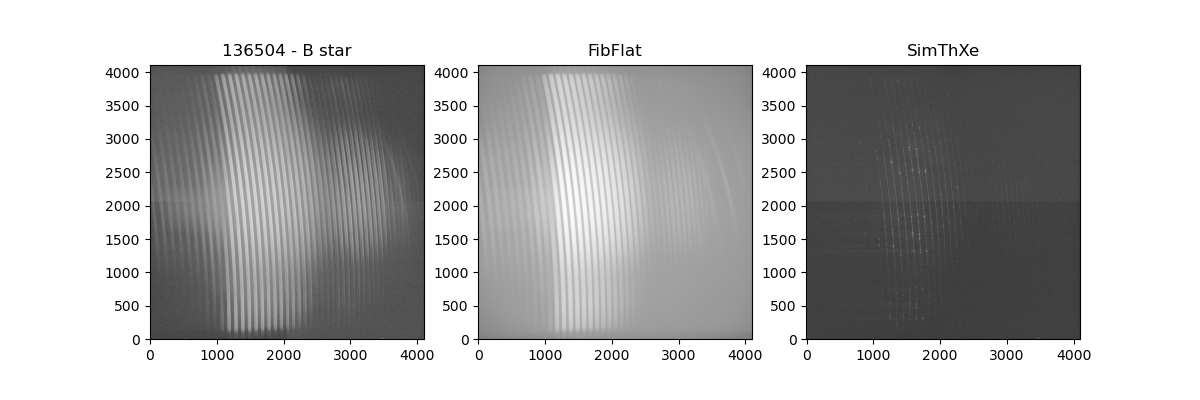

In [107]:
plt.close('all')
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image_subtracted_bias, cmap='gray', norm="symlog", origin='lower', rasterized=True)
axes[0].set_title(f'{header["OBJECT"]} - B star')
axes[1].imshow(flat_subtracted_bias, cmap='gray', norm="symlog", origin='lower', rasterized=True)
axes[1].set_title(f'FibFlat')
axes[2].imshow(simTh_subtracted_bias, cmap='gray', norm="symlog", origin='lower', rasterized=True)
axes[2].set_title(f'SimThXe')
plt.savefig(f'{veloce_paths.output_dir}/{arm}_arm_examples.pdf', dpi=600, bbox_inches='tight')
plt.show()

### Determine trace shift with ccf

In [ ]:
# from simple_veloce_reduction import veloce_extraction

In [98]:
run = 'Trace_shift'
# run = 'Delta_Call_2025_accretion'
date_1 = '240523'
date_2 = '240620'
# date = '250406'
arm = 'blue'
# arm = 'green'
# arm = 'red'
ccd = f'ccd_{arm_n[arm]}'
amplifier_mode = 4

science_targets = [None]

In [99]:
input_dir = f'~/VeloceData/{run}/'
output_dir = f'~/VeloceExtracted/Trace/'
veloce_paths = veloce_config.VelocePaths(input_dir=input_dir, output_dir=output_dir)
config = veloce_config.make_config(input_dir, output_dir, date=date_1, arm=arm, amplifier_mode=amplifier_mode)
obs_list = veloce_config.load_night_logs(science_targets, veloce_paths, config)

In [100]:
# flat_filename =  os.path.join(input_dir, date_1, ccd, '23may30021.fits') # red
# flat_filename =  os.path.join(input_dir, date_1, ccd, '23may20031.fits') # green
flat_filename =  os.path.join(input_dir, date_1, ccd, '23may10041.fits') # blue
with fits.open(flat_filename) as hdul:
    flat_data_1 = hdul[0].data
    header_1 = hdul[0].header

# flat_filename =  os.path.join(input_dir, date_2, ccd, '20jun30011.fits') # red
# flat_filename =  os.path.join(input_dir, date_2, ccd, '20jun20016.fits') # green
flat_filename =  os.path.join(input_dir, date_2, ccd, '20jun10021.fits') # blue
with fits.open(flat_filename) as hdul:
    flat_data_2 = hdul[0].data
    header_2 = hdul[0].header

In [155]:
trace_filename = os.path.join(veloce_paths.trace_dir, f'veloce_{arm}_4amp_sim_calib_trace.pkl')
traces = veloce_reduction_tools.Traces.load_traces(trace_filename)

In [ ]:
# trace_filename = os.path.join(veloce_paths.trace_dir, f'veloce_{arm}_4amp_no_sim_calib_trace.pkl')
# traces_2 = veloce_reduction_tools.Traces.load_traces(trace_filename)

In [103]:
flat_subtracted_bias_1 = veloce_reduction_tools.remove_overscan_bias(flat_data_1, hdr=header_1, arm=arm, amplifier_mode=amplifier_mode, overscan_range=32)
flat_subtracted_bias_2 = veloce_reduction_tools.remove_overscan_bias(flat_data_2, hdr=header_2, arm=arm, amplifier_mode=amplifier_mode, overscan_range=32)

In [104]:
%matplotlib widget

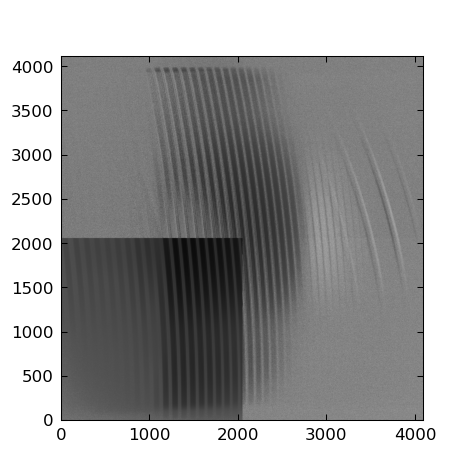

In [105]:
plt.close('all')
fig, axes = plt.subplots(1, 1, figsize=(3.15, 3.15))
axes.imshow(flat_subtracted_bias_1-flat_subtracted_bias_2, cmap='gray', norm='symlog', origin='lower')
plt.show()

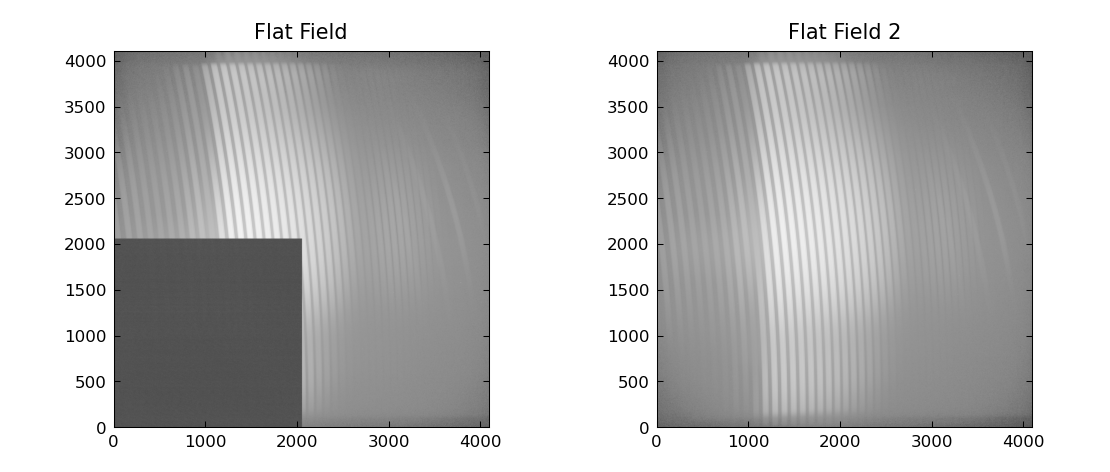

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.15))
axes[0].imshow(flat_subtracted_bias_1, cmap='gray', norm='symlog', origin='lower')
axes[0].set_title('Flat Field')
axes[1].imshow(flat_subtracted_bias_2, cmap='gray', norm='symlog', origin='lower')
axes[1].set_title('Flat Field 2')
# for idx, (trace_y, trace_x, lower, upper) in enumerate(traces):
#     axes[0].plot(trace_x, trace_y, c='r')
#     axes[1].plot(trace_x, trace_y, c='r')

#     axes[0].annotate(str(idx), (trace_x[len(trace_x)//2]+upper, trace_y[len(trace_y)//2]), color='red', fontsize=8)
#     axes[0].plot(trace_x+upper,trace_y, ls=':', c='r')
#     axes[0].plot(trace_x-lower,trace_y, ls='--', c='r')
    
#     axes[1].annotate(str(idx), (trace_x[len(trace_x)//2]+upper, trace_y[len(trace_y)//2]), color='red', fontsize=8)
#     axes[1].plot(trace_x+upper,trace_y, ls=':', c='r')
#     axes[1].plot(trace_x-lower,trace_y, ls='--', c='r')
plt.tight_layout()
plt.show()

In [97]:
# pix_shift, ccf = determine_trace_shift(image_subtracted_bias_2, reference_image=image_subtracted_bias, row=2000)
# pix_shift, ccf = determine_trace_shift(image_subtracted_bias_2, reference_image=image_subtracted_bias)
h_shift, pix_shift, ccf = veloce_reduction_tools.Traces.determine_trace_shift(flat_subtracted_bias_2, reference_frame=flat_subtracted_bias_1)
print(f'Horizontal shift between two flats: {h_shift} pixels')

Horizontal shift between two flats: 3.0 pixels


In [ ]:
shift_template = {}
for row in range(300, flat_subtracted_bias_2.shape[0]-300, 50):
    shift_template[row] = flat_subtracted_bias_2[row,:]
with open(os.path.join(veloce_paths.trace_dir, f'trace_{arm}_shift_template.pkl'), 'wb') as f:
    pickle.dump(shift_template, f)

In [ ]:
shift, pix_shift, ccf = veloce_reduction_tools.Traces.determine_trace_shift_template(flat_subtracted_bias_2, arm)
shift

3.0

In [ ]:
traces_2.adjust_traces_with_ccf(flat_subtracted_bias_2, arm)

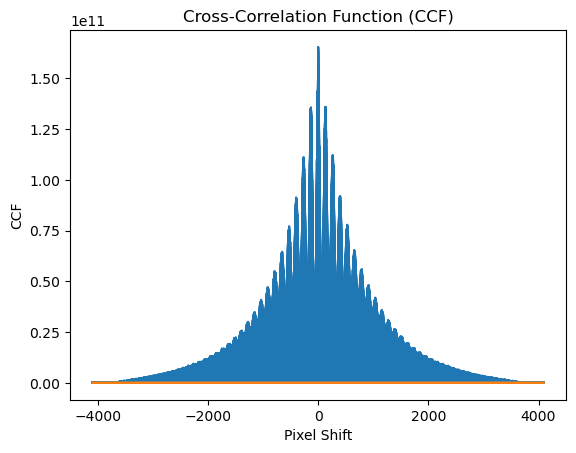

In [29]:
plt.close('all')
for _ccf in ccf:
    plt.plot(pix_shift, _ccf)
plt.xlabel('Pixel Shift')
plt.ylabel('CCF')
plt.title('Cross-Correlation Function (CCF)')
plt.show()

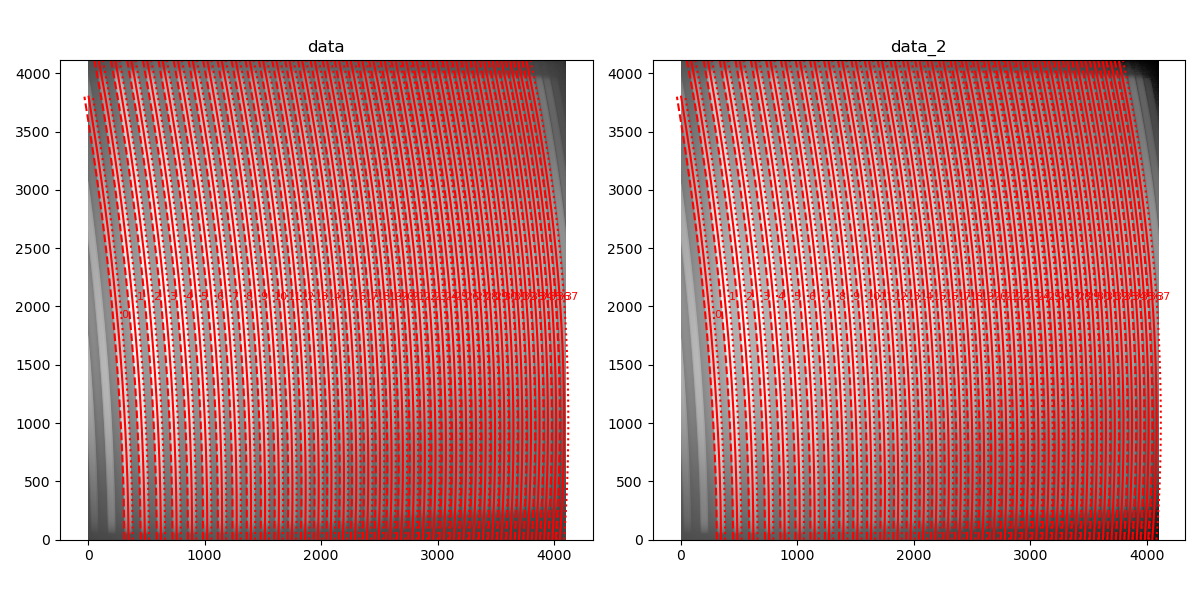

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.15))
axes[0].imshow(flat_subtracted_bias, cmap='gray', norm='symlog', origin='lower')
axes[0].set_title('Flat Field')
axes[1].imshow(flat_subtracted_bias_2, cmap='gray', norm='symlog', origin='lower')
axes[1].set_title('Flat Field 2')
for idx, (trace_y, trace_x, lower, upper) in enumerate(traces):
    axes[0].plot(trace_x, trace_y, c='r')
    axes[0].annotate(str(idx), (trace_x[len(trace_x)//2]+upper, trace_y[len(trace_y)//2]), color='red', fontsize=8)
    axes[0].plot(trace_x+upper,trace_y, ls=':', c='r')
    axes[0].plot(trace_x-lower,trace_y, ls='--', c='r')
for idx, (trace_y, trace_x, lower, upper) in enumerate(traces_2):
    axes[1].plot(trace_x, trace_y, c='r') 
    axes[1].annotate(str(idx), (trace_x[len(trace_x)//2]+upper, trace_y[len(trace_y)//2]), color='red', fontsize=8)
    axes[1].plot(trace_x+upper,trace_y, ls=':', c='r')
    axes[1].plot(trace_x-lower,trace_y, ls='--', c='r')
plt.tight_layout()
plt.show()

In [131]:
extracted_orders_1, _, extracted_order_imgs_1 = veloce_reduction_tools.extract_orders_with_trace(
                            flat_subtracted_bias, traces, remove_background=False)
extracted_orders_2, _, extracted_order_imgs_2 = veloce_reduction_tools.extract_orders_with_trace(
                            flat_subtracted_bias_2, traces, remove_background=False)

In [132]:
print(len(traces))
for y, x, lower, upper in traces:
    print(f'Trace center at y={y[len(y)//2]}, x={x[len(x)//2]}, lower={lower}, upper={upper}')  

29
Trace center at y=1975.0, x=1080.51357022276, lower=26, upper=26
Trace center at y=1975.0, x=1186.0253633861, lower=26, upper=26
Trace center at y=1975.0, x=1289.44639532091, lower=26, upper=26
Trace center at y=1975.0, x=1392.03594146311, lower=26, upper=26
Trace center at y=1975.0, x=1492.6051344469, lower=26, upper=26
Trace center at y=1975.0, x=1591.4839983029, lower=26, upper=26
Trace center at y=1975.0, x=1688.05308976065, lower=26, upper=26
Trace center at y=1975.0, x=1785.00764837661, lower=26, upper=26
Trace center at y=1975.0, x=1878.96588607611, lower=26, upper=26
Trace center at y=1975.0, x=1971.93643689174, lower=26, upper=26
Trace center at y=1975.0, x=2063.20866528375, lower=26, upper=26
Trace center at y=1975.0, x=2153.66685796357, lower=26, upper=26
Trace center at y=1975.0, x=2241.87887270412, lower=26, upper=26
Trace center at y=1975.0, x=2328.42108795276, lower=26, upper=26
Trace center at y=2250.0, x=2386.59297531282, lower=26, upper=26
Trace center at y=2100.0,

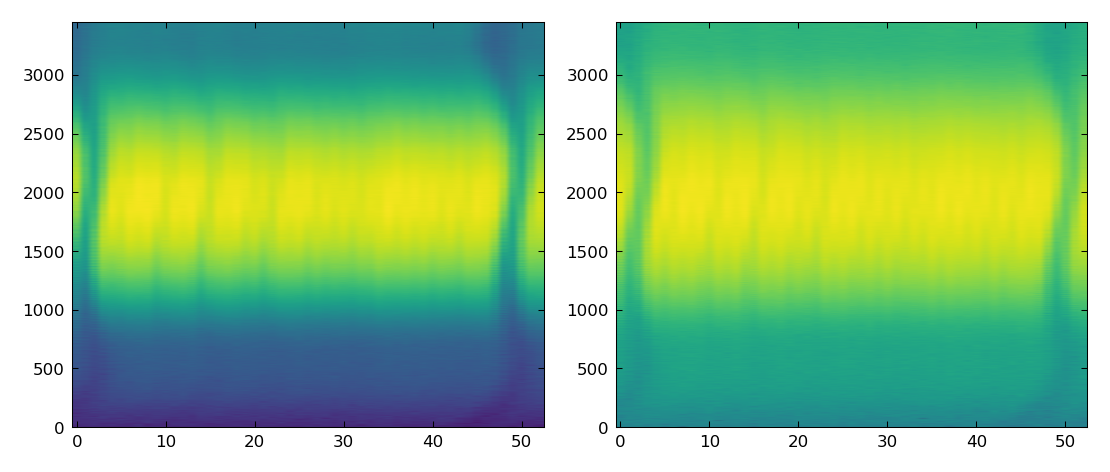

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.15))
axes[0].imshow(extracted_order_imgs_1[12], norm='symlog', origin='lower', aspect='auto')
axes[1].imshow(extracted_order_imgs_2[12], norm='symlog', origin='lower', aspect='auto')
plt.tight_layout()
plt.show()

##### Determine summing range

In [33]:
summing_ranges = [(50, 50) for _ in traces.summing_ranges_upper]

In [34]:
traces.set_summing_range(summing_ranges)

In [35]:
extracted_orders, extracted_order_imgs = veloce_reduction_tools.extract_orders_with_trace(
                            data, traces, remove_background=False)

In [36]:
%matplotlib widget

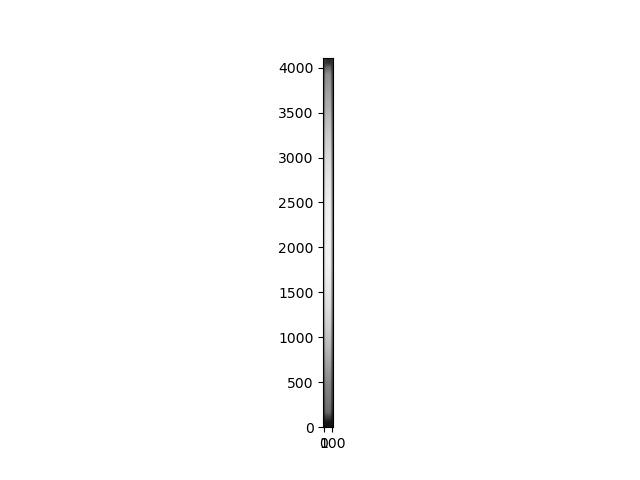

In [37]:
plt.close('all')
plt.imshow(extracted_order_imgs[10], cmap='gray', norm='symlog', origin='lower')
plt.show()

In [54]:
# from scipy.ndimage import gaussian_filter
from scipy.signal import find_peaks

In [55]:
def find_summing_range(image, traces, search_box=50, plot=False, peak_mode='closest'):
    lower, upper = [], []
    if plot:
        print(f'Plotting trace extraction for order {plot}')
    if plot == True:
        plot = 10
    for idx, (trace_y, trace_x, _, _) in enumerate(traces):
        minima_l = []
        minima_r = []
        for row, x in zip(trace_y, trace_x):
            lower_bound = int(max(0, x - search_box))
            center = int(search_box) if x - search_box >= 0 else int(x)
            upper_bound = int(min(image.shape[1], x + search_box))
            row_data = image[int(row), lower_bound:upper_bound].copy()
            row_data -= np.max(row_data)
            row_data *= -1
            _height = np.median(row_data) + (np.max(row_data) - np.median(row_data))/2
            # _height = np.max(row_data)/2
            peaks, _ = find_peaks(row_data, height=_height, distance=3)
            # peaks = np.where(row_data > _height)[0]

            peaks_l = peaks[peaks < center]
            peaks_r = peaks[peaks > center]

            # Select peak based on peak_mode
            if len(peaks_l) > 0:
                if peak_mode == 'closest':
                    closest_peak = peaks_l[np.argmin(np.abs(peaks_l - center))]
                    minima_l.append(center - closest_peak)
                elif peak_mode == '2nd' and len(peaks_l) > 1:
                    sorted_l = np.argsort(np.abs(peaks_l - center))
                    second_peak = peaks_l[sorted_l[1]]
                    minima_l.append(center - second_peak)
                else:
                    minima_l.append(np.nan)
            else:
                minima_l.append(np.nan)

            if len(peaks_r) > 0:
                if peak_mode == 'closest':
                    closest_peak = peaks_r[np.argmin(np.abs(peaks_r - center))]
                    minima_r.append(closest_peak - center)
                elif peak_mode == '2nd' and len(peaks_r) > 1:
                    sorted_r = np.argsort(np.abs(peaks_r - center))
                    second_peak = peaks_r[sorted_r[1]]
                    minima_r.append(second_peak - center)
                else:
                    minima_r.append(np.nan)
            else:
                minima_r.append(np.nan)

            if idx == plot and row == 2000:
                plt.close('all')
                plt.figure()
                plt.plot(row_data, 'k-')
                plt.plot(peaks, row_data[peaks], "x")
                plt.axvline(center, color='r', linestyle='--', label='Trace Center')
                if minima_l[-1] is not np.nan:
                    plt.axvline(center - minima_l[-1], color='g', linestyle='--', label='Left Minimum')
                if minima_r[-1] is not np.nan:
                    plt.axvline(center + minima_r[-1], color='b', linestyle='--', label='Right Minimum')
                plt.xlabel('Pixel')
                plt.ylabel('Counts')
                plt.title(f'Row {row}, Order {idx}')
                plt.legend()
                plt.show()
        lower.append(int(np.nanmedian(minima_l))+1)
        upper.append(int(np.nanmedian(minima_r))+1)
    if len(lower) != len(traces):
        print(f'Warning: found {len(lower)} summing ranges, but {len(traces)} traces')
    return np.array(lower), np.array(upper)
        

In [39]:
from simple_veloce_reduction import veloce_extraction

In [104]:
data_bkg, hdr = veloce_extraction.remove_scattered_light(data, header, traces, diagnostic=False)

Plotting trace extraction for order 9


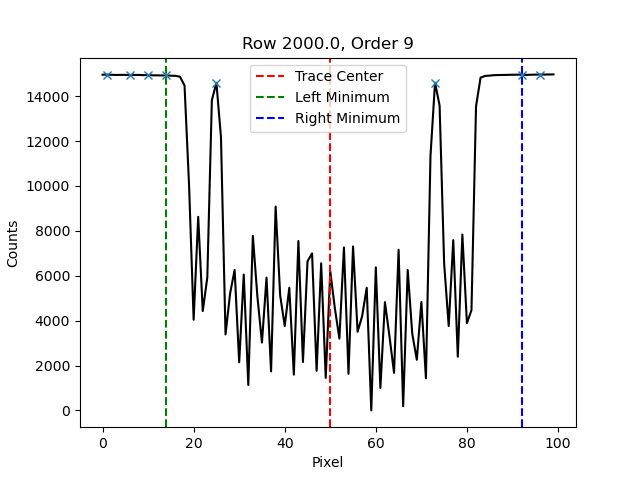

In [ ]:
# _lower, _upper = find_summing_range(data, traces, search_box=50, plot=30, peak_mode='closest')
_lower, _upper = veloce_reduction_tools.Traces.determine_summing_range(data, traces, search_box=50, plot=9, peak_mode='2nd')

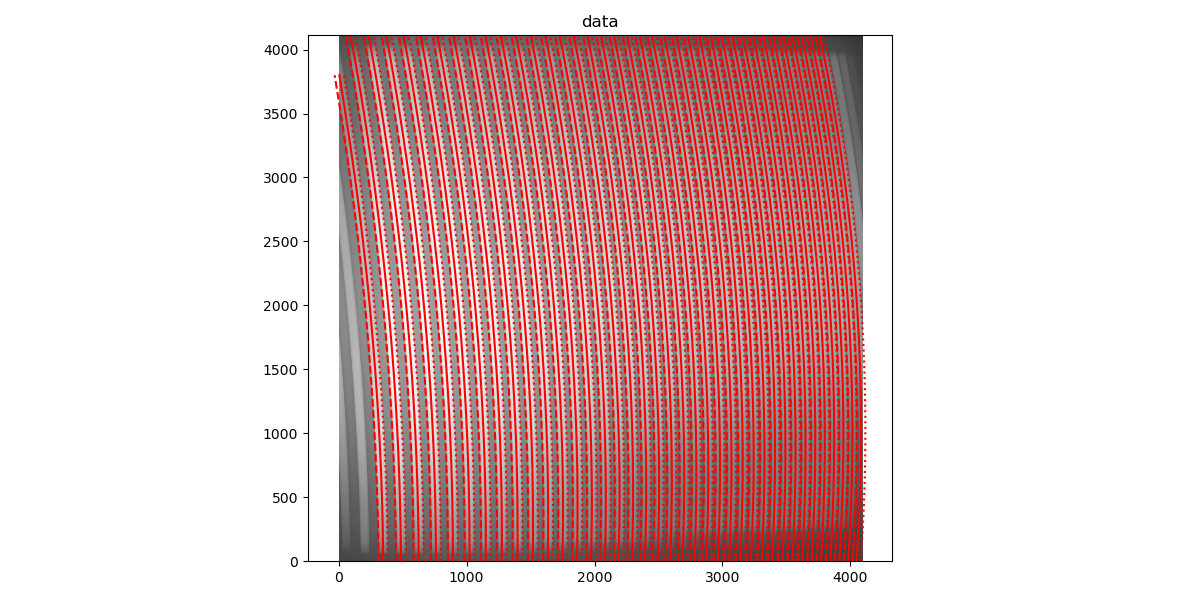

In [57]:
fig, axes = plt.subplots(1, 1, figsize=(12, 6))
# axes.imshow(data, cmap='gray', norm='symlog', origin='lower')
axes.imshow(data, cmap='gray', norm='symlog', origin='lower')
axes.set_title('data')
for (trace_y, trace_x, _, _), lower, upper in zip(traces, _lower, _upper):
    axes.plot(trace_x, trace_y, c='r')
    # axes[0].annotate(str(idx), (trace_x[len(trace_x)//2]+upper, trace_y[len(trace_y)//2]), color='red', fontsize=8)
    axes.plot(trace_x+upper,trace_y, ls=':', c='r')
    axes.plot(trace_x-lower,trace_y, ls='--', c='r')
plt.tight_layout()
plt.show()

In [58]:
# for lower, upper in zip(_lower, _upper):
#     print(lower, upper, lower+upper)

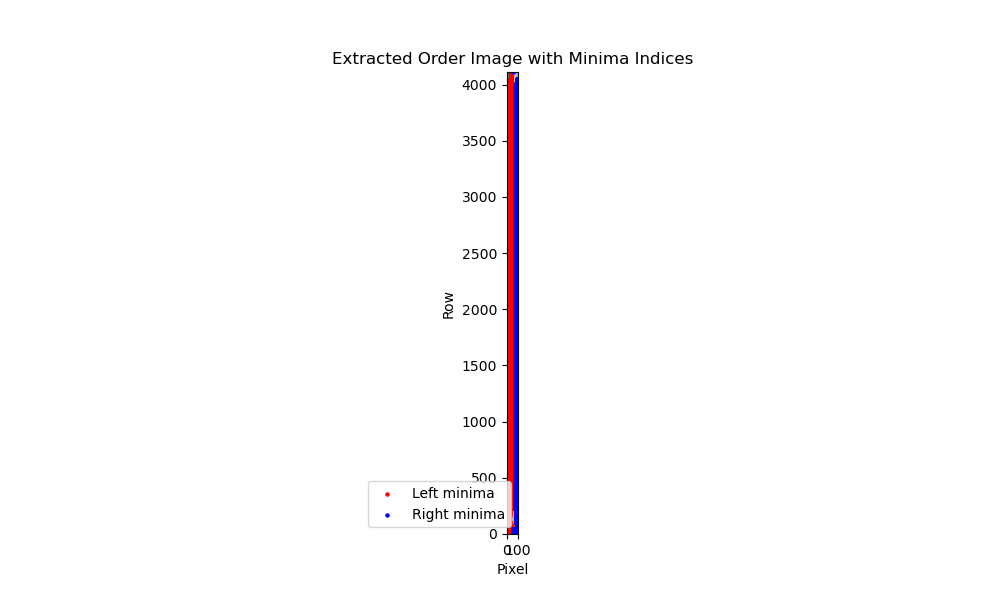

In [ ]:
# plt.figure(figsize=(10, 6))
# plt.imshow(extracted_order_imgs[10], cmap='gray', norm='symlog', origin='lower')
# plt.scatter(minima_indices_l, np.arange(len(minima_indices_l)), color='red', s=5, label='Left minima')
# plt.scatter(minima_indices_r, np.arange(len(minima_indices_r)), color='blue', s=5, label='Right minima')
# plt.xlabel('Pixel')
# plt.ylabel('Row')
# plt.legend()
# plt.title('Extracted Order Image with Minima Indices')
# plt.show()

### 2a. Load prefitted traces for calib fibres

Load prefitted trace to refit or skip to determining orders from flux in flat images

In [29]:
shift = -27
order_nums, coeffs, new_traces = veloce_reduction_tools.load_prefitted_wavecalib_trace(arm=arm, calib_type='Th')
new_traces = veloce_reduction_tools.Traces(traces = new_traces)
new_traces.set_traces_yx(y=new_traces.y, x=[x + shift for x in new_traces.x])

In [30]:
trace_path = veloce_paths.trace_dir
if not os.path.exists(trace_path):
    print(f"{trace_path} does not exist")
trace_filename = f'veloce_{arm}_4amp_sim_calib_trace.pkl'
traces = veloce_reduction_tools.Traces.load_traces(os.path.join(trace_path, trace_filename))
# trace_filename = f'veloce_{arm}_4amp_sim_calib_trace.pkl'
# new_traces = veloce_reduction_tools.Traces.load_traces(os.path.join(trace_path, trace_filename))

In [143]:
# old format for saved traces
# trace_data = np.load('./Trace/veloce_green_4amp_no_sim_calib_trace.npz')
# traces, summing_ranges = trace_data['traces'], trace_data['summing_ranges']

In [144]:
# def plot_traces_on_image(ax, traces, c, order_nums=None):
#     # ax.imshow(image, cmap='gray', norm='symlog', origin='lower')
#     for idx, (trace_y, trace_x, lower, upper) in enumerate(traces):
#         ax.plot(trace_x, trace_y, c=c)
#         ax.plot(trace_x+upper, trace_y, c=c, linestyle=':')
#         ax.plot(trace_x-lower, trace_y, c=c, linestyle='--')
#         if order_nums is not None:
#             ax.annotate(str(order_nums[idx]), (trace_x[len(trace_x)//2]+1, trace_y[len(trace_y)//2]), color=c, fontsize=8)

In [31]:
for idx, (trace_y, trace_x, lower, upper) in enumerate(new_traces):
    print(f'Order {idx}: lower = {lower}, upper = {upper}, lower+upper = {lower+upper}')

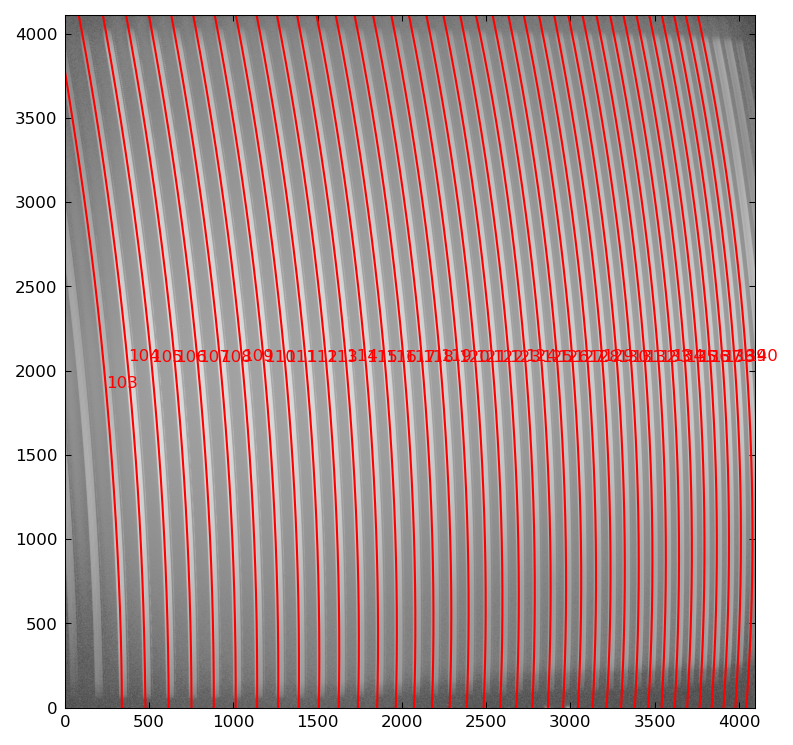

In [146]:
plt.close('all')
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image_subtracted_bias, cmap='gray', norm="symlog", origin='lower')
# plot_traces_on_image(ax, traces, 'b', order_nums=order_nums)
# plot_traces_on_image(ax, new_traces, 'r', order_nums=order_nums)
c = 'r'
for idx, (trace_y, trace_x) in enumerate(new_traces.traces):
    ax.plot(trace_x, trace_y, c=c)
    # ax.plot(trace_x+upper, trace_y, c=c, linestyle=':')
    # ax.plot(trace_x-lower, trace_y, c=c, linestyle='--')
    if order_nums is not None:
        ax.annotate(str(order_nums[idx]), (trace_x[len(trace_x)//2]+1, trace_y[len(trace_y)//2]), color=c, fontsize=8)
ax.set_xlim(0, image_subtracted_bias.shape[1])
ax.set_ylim(0, image_subtracted_bias.shape[0])
plt.show()

In [65]:
plt.close()

In [36]:
''' 
shape is consistent with info from manual 
but there is a row of 'bias' pixels at the top of the image (row 4111)
'''
# image_subtracted_bias.shape

" \nshape is consistent with info from manual \nbut there is a row of 'bias' pixels at the top of the image (row 4111)\n"

### 2b. Detect flux through thresholding to get initial trace for each order

skip when refitting existing trace

In [123]:
if arm == 'blue':
    blured = median_filter(image_subtracted_bias, (5,15)) #blue
elif arm == 'green':
    blured = median_filter(image_subtracted_bias, (1,21)) #green
elif arm == 'red':
    blured = median_filter(image_subtracted_bias, (10,10)) #red

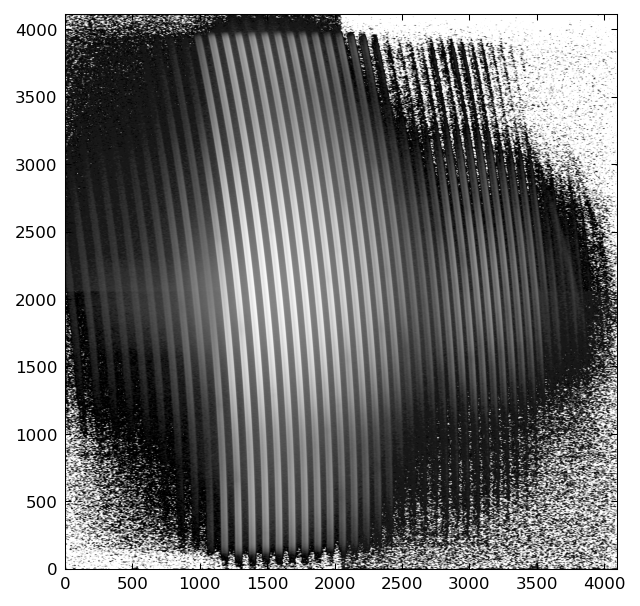

In [124]:
plt.figure()
plt.imshow(blured, cmap='gray', norm='log', origin='lower')
plt.show()
# blured = image_substracted_bias

In [125]:
plt.close()

(<Figure size 960x720 with 1 Axes>,
 <Axes: title={'center': 'Cross-section at row 2000'}, xlabel='Pixel', ylabel='Counts'>)

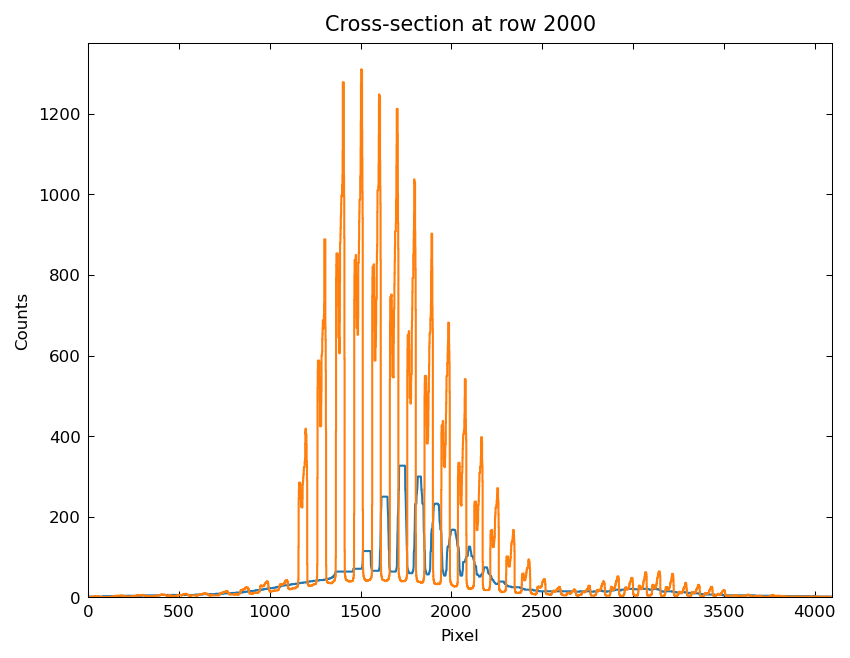

In [126]:
n = 2000
# veloce_reduction_tools.plot_cross_section(image_substracted_bias, n, axis='x')
veloce_reduction_tools.plot_cross_section(blured, n, axis='x')

In [127]:
plt.close('all')


Result: pixels belonging to orders, this is done on flats.

Threshold detected per row, as median filter with wide span

In [128]:
binarized = veloce_reduction_tools.get_binary_mask(blured, arm=arm, axis='x')

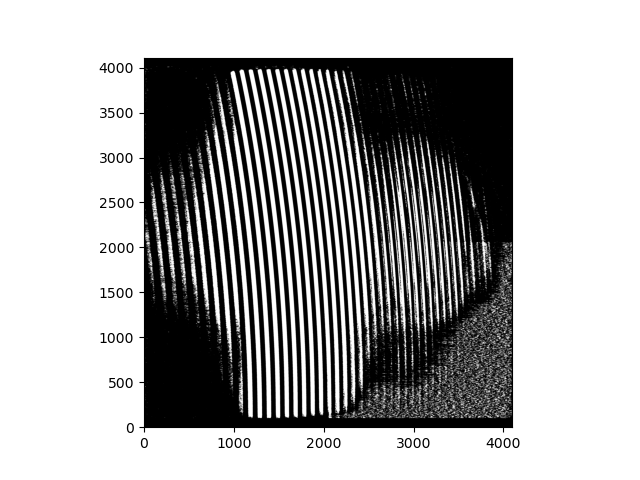

In [72]:
plt.figure()
plt.imshow(binarized, cmap='gray', origin='lower')
plt.show()

In [73]:
plt.close()

In [80]:
orders = veloce_reduction_tools.get_orders_masks(binarized)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..65025].


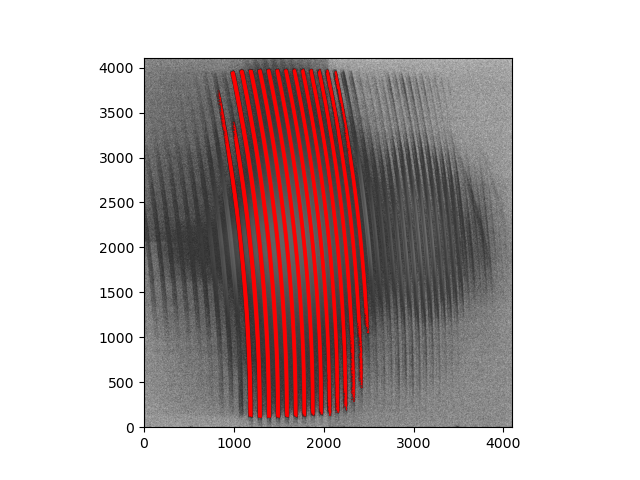

In [ ]:
img_orders = merge_masks_with_alpha(orders)
plt.figure()
# plt.imshow(image_subtracted_bias, cmap='gray', norm='log', origin='lower')
plt.imshow(image_subtracted_bias, cmap='gray', norm='log', origin='lower')
plt.imshow(img_orders, origin='lower')
plt.show()

In [115]:
traces = get_traces_simple(image_subtracted_bias, orders, poly_order=5, fit_width=30)

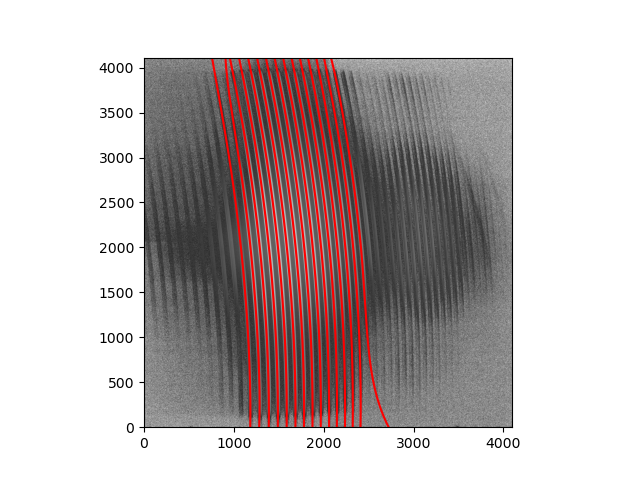

In [116]:
# img_orders = merge_masks_with_alpha(orders)
plt.figure()
# plt.imshow(image_subtracted_bias, cmap='gray', norm='log', origin='lower')
plt.imshow(image_subtracted_bias, cmap='gray', norm='log', origin='lower')
for trace_y, trace_x in traces:
    plt.plot(trace_x, trace_y, c='r')
# plt.imshow(img_orders, origin='lower')
plt.show()

In [96]:
# orders = veloce_reduction_tools.get_orders_masks(binarized)
_orders = get_orders_masks(binarized, order_number_goal=len(new_traces)*2)

Found 28982 connected components in the binarized image.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0..65025].


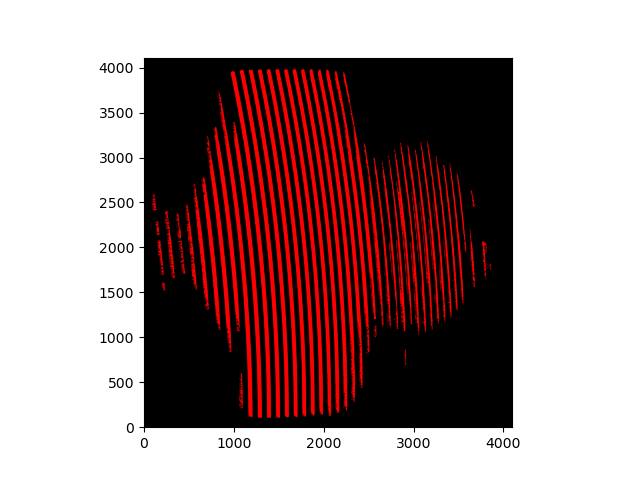

In [97]:
img_orders = merge_masks_with_alpha(_orders)
plt.figure()
# plt.imshow(image_subtracted_bias, cmap='gray', norm='log', origin='lower')
plt.imshow(binarized, cmap='gray', norm='log', origin='lower')
plt.imshow(img_orders, origin='lower')
plt.show()

In [84]:
len(orders), len(_orders)

(15, 12)

In [27]:
plt.close('all')

del img_orders
gc.collect()

3285

In [ ]:
len(orders)

39

### 3. Get and smooth the trace or adjust existing one

average in x direction, and fit the polynomial

In [21]:
# traces = veloce_reduction_tools.get_traces(image_subtracted_bias, orders)

In [30]:
# del orders
# gc.collect()

Adjust existing traces by shifting in cross dispersion direction (x) to align with mid position determined by weighted average around initial trace.

In [65]:
# new_traces = veloce_reduction_tools.Traces([(y, x-21) for y, x in traces])

In [36]:
fit_width = 35 # green
# fit_width = 25 # red
# fit_width = 40 # blue
# fit_width = np.max(np.array([traces.summing_ranges_lower, traces.summing_ranges_upper]))

In [38]:
# traces = veloce_reduction_tools.refit_traces(image_subtracted_bias, x, y, fit_width=20)
# traces = veloce_reduction_tools.adjust_traces(image_subtracted_bias, x, y)
new_traces.adjust_traces(image_subtracted_bias, fit_width=fit_width, tolerance=1e-5)
# new_traces.adjust_traces(blured, fit_width=fit_width, tolerance=1e-5)

In [ ]:
new_traces.refit_traces(blured, fit_width=fit_width, tolerance=1e-5)

In [156]:
# load wave calibration based on ThAr
ORDER, COEFFS, MATCH_LAM, MATCH_PIX, MATCH_LRES, GUESS_LAM, Y0 = veloce_reduction_tools.load_prefitted_wave(arm=arm, wave_path=veloce_paths.wave_dir)

In [40]:
print(len(new_traces), len(COEFFS))

38 38


In [41]:
for order_trace, order_wave in zip(order_nums, ORDER):
    print(order_trace, order_wave)

103 103
104 104
105 105
106 106
107 107
108 108
109 109
110 110
111 111
112 112
113 113
114 114
115 115
116 116
117 117
118 118
119 119
120 120
121 121
122 122
123 123
124 124
125 125
126 126
127 127
128 128
129 129
130 130
131 131
132 132
133 133
134 134
135 135
136 136
137 137
138 138
139 139
140 140


In [66]:
# new_traces.set_traces(new_traces.traces[1:])

In [26]:
# traces = veloce_reduction_tools.Traces(traces=new_traces, summing_ranges=summing_ranges, wavelength_slice=slice(None))

In [19]:
plt.close('all')

### 4. Work out summing range

I wanted to work out a criteria for that but in the end it was more practical to check flat, science and calibration (simultanious Th and LC) data to place borders for data extraction.

The Flat data has light in the sky fibers so the trace is ofset to the side with 3 sky fibers, this is fixed by assymetric summing range.

In [42]:
%matplotlib inline

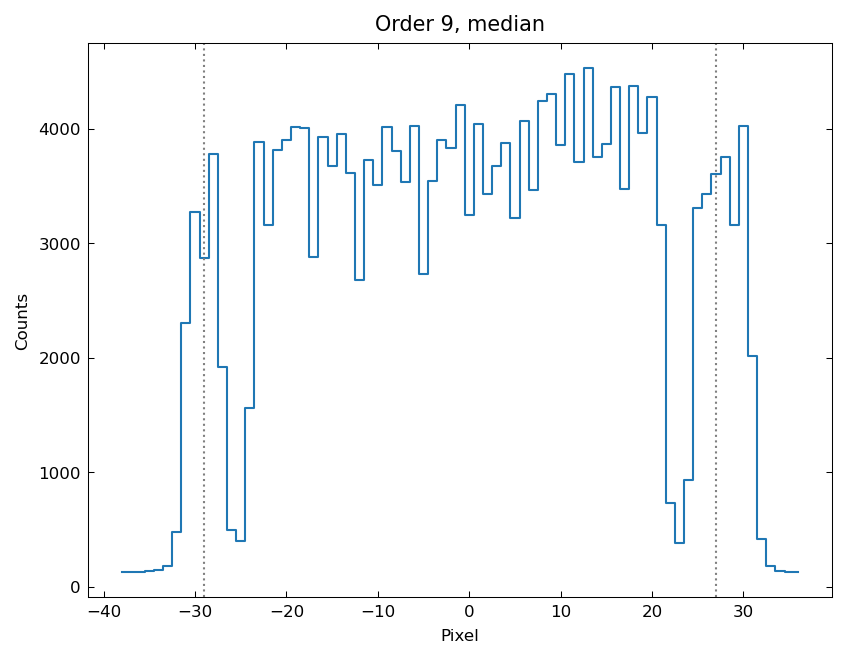

In [43]:
plt.close('all')
plt.figure()
extracted_order_image = veloce_reduction_tools.plot_order_cross_section(flat_subtracted_bias, traces, 9, plot_type='median', margin=[10,10])    
plt.show()

In [44]:
arm

'green'

Order 0: summing range = [28, 26]
75 75
Estimated summing range: lower = 26, upper = 24
Order 1: summing range = [28, 26]
75 75
Estimated summing range: lower = 26, upper = 24
Order 2: summing range = [28, 26]
75 75
Estimated summing range: lower = 26, upper = 24
Order 3: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 24
Order 4: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 24
Order 5: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 24
Order 6: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 24
Order 7: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 24
Order 8: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 24
Order 9: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 24
Order 10: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 24
Order 11: summing range = [28, 

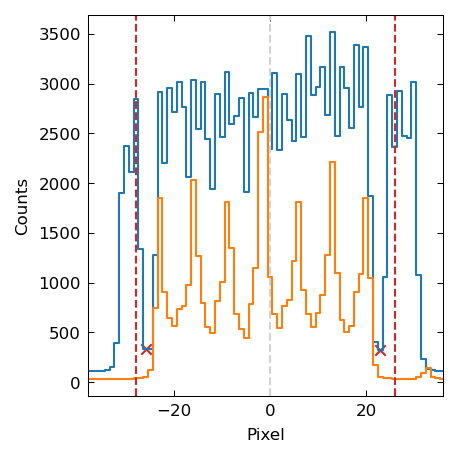

Estimated summing range: lower = 26, upper = 24
Order 12: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 24
Order 13: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 23
Order 14: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 23
Order 15: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 23
Order 16: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 23
Order 17: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 23
Order 18: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 23
Order 19: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 23
Order 20: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 23
Order 21: summing range = [28, 26]
75 75
Estimated summing range: lower = 25, upper = 23
Order 22: summing range = [28, 26]
75 75
Estimated summing ran

In [46]:
%matplotlib inline
fit_margin = 10
for idx, (trace_y, trace_x, lower, upper) in enumerate(traces):
    
    # plt.close('all')
    # plt.figure()
    # extracted_order_image = veloce_reduction_tools.plot_order_cross_section(flat_subtracted_bias, traces, idx, plot_type='median', margin=[10,10])    
    # plt.show()
    print(f'Order {idx}: summing range = [{lower}, {upper}]')
    estimated_lower = []
    estimated_upper = []
    plt.close('all')
    flat_order_image = veloce_reduction_tools.plot_order_cross_section(flat_subtracted_bias, traces, idx, plot_type='median', margin=[fit_margin,fit_margin])
    star_order_image = veloce_reduction_tools.plot_order_cross_section(image_subtracted_bias, traces, idx, plot_type='median', margin=[fit_margin,fit_margin])
    # plt.show()
    plt.close()
    x = np.arange(-lower-fit_margin,upper+fit_margin+1)
    order_row = np.median(flat_order_image, axis=0)
    star_row = np.median(star_order_image, axis=0)
    print(len(order_row), len(x))
    _order_row = -1*order_row
    _order_row -= np.min(_order_row)
    peaks = find_peaks(_order_row, height=np.median(_order_row)+np.std(_order_row))[0]
    # get closest peaks to the center at each side
    l = peaks[peaks < fit_width][-1] if np.any(peaks < fit_width) else np.nan
    u = peaks[peaks > fit_width][0] if np.any(peaks > fit_width) else np.nan
    # print(peaks - fit_width)
    fit_width = lower + fit_margin

    if idx == 11:
        # plt.figure()
        fig, axes = plt.subplots(1, 1, figsize=(3.15, 3.15))
        axes.step(x, order_row, 'C0', where='mid')
        axes.scatter(x[peaks], order_row[peaks], marker="x", color="C3")
        axes.step(x, star_row, 'C1', where='mid')
        axes.axvline(-1*lower, color='C3', linestyle='--')
        axes.axvline(0, color='lightgrey', linestyle='--')
        axes.axvline(upper, color='C3', linestyle='--')
        axes.set_xlabel('Pixel')
        axes.set_ylabel('Counts')
        axes.set_xlim(x[0], x[-1])

        # axes[1].step(x, star_row, 'C0', where='mid')
        # axes[1].scatter(x[peaks], star_row[peaks], marker="x", color="C3")
        # axes[1].axvline(-1*lower, color='C3', linestyle='--')
        # axes[1].axvline(upper, color='C3', linestyle='--')
        # axes[1].set_xlabel('Pixel')
        # axes[1].set_ylabel('Counts')
        # axes[1].set_xlim(x[0], x[-1])
        # plt.legend()
        plt.tight_layout()
        plt.savefig(f'{veloce_paths.output_dir}/summing_range_determination_{arm}_order_{idx}.pdf', dpi=600, bbox_inches='tight')
        plt.show()


    estimated_lower.append(abs(l-fit_width) if not np.isnan(l) else np.nan)
    estimated_upper.append(abs(u-fit_width) if not np.isnan(u) else np.nan)
    print(f'Estimated summing range: lower = {int(np.nanmedian(estimated_lower))}, upper = {int(np.nanmedian(estimated_upper))+1}')

Order 0: summing range = [22, 24]
Estimated summing range: lower = 20, upper = 22
Order 1: summing range = [22, 24]
Estimated summing range: lower = 20, upper = 23
Order 2: summing range = [22, 24]
Estimated summing range: lower = 20, upper = 23
Order 3: summing range = [22, 24]
Estimated summing range: lower = 20, upper = 23
Order 4: summing range = [22, 24]
Estimated summing range: lower = 20, upper = 23
Order 5: summing range = [22, 24]
Estimated summing range: lower = 20, upper = 23
Order 6: summing range = [22, 24]
Estimated summing range: lower = 20, upper = 24
Order 7: summing range = [22, 24]
Estimated summing range: lower = 20, upper = 24
Order 8: summing range = [22, 24]
Estimated summing range: lower = 20, upper = 24
Order 9: summing range = [22, 24]
Estimated summing range: lower = 20, upper = 24
Order 10: summing range = [22, 24]
Estimated summing range: lower = 20, upper = 24
Order 11: summing range = [22, 24]
Estimated summing range: lower = 20, upper = 24
Order 12: summ

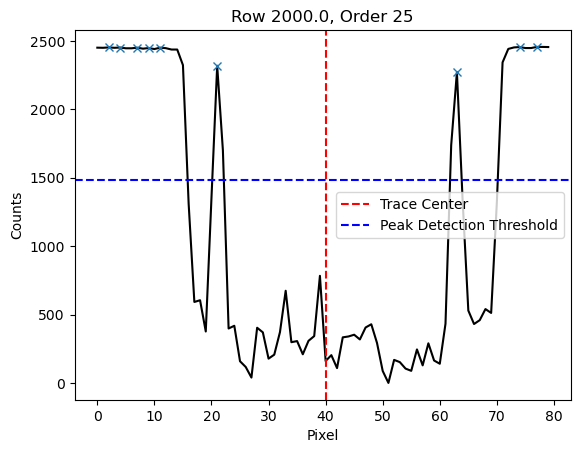

Estimated summing range: lower = 20, upper = 24
Order 26: summing range = [22, 24]
Estimated summing range: lower = 19, upper = 24
Order 27: summing range = [22, 24]
Estimated summing range: lower = 19, upper = 24
Order 28: summing range = [22, 24]
Estimated summing range: lower = 20, upper = 24
Order 29: summing range = [22, 24]
Estimated summing range: lower = 20, upper = 24
Order 30: summing range = [22, 24]
Estimated summing range: lower = 20, upper = 24
Order 31: summing range = [22, 24]
Estimated summing range: lower = 19, upper = 24
Order 32: summing range = [22, 24]
Estimated summing range: lower = 19, upper = 24
Order 33: summing range = [22, 24]
Estimated summing range: lower = 20, upper = 23
Order 34: summing range = [22, 24]
Estimated summing range: lower = 20, upper = 23
Order 35: summing range = [22, 24]
Estimated summing range: lower = 19, upper = 23
Order 36: summing range = [22, 24]
Estimated summing range: lower = 19, upper = 23
Order 37: summing range = [22, 24]
Esti

In [73]:
fit_width = 40
for idx, (trace_y, trace_x, lower, upper) in enumerate(traces):
    
    # plt.close('all')
    # plt.figure()
    # extracted_order_image = veloce_reduction_tools.plot_order_cross_section(flat_subtracted_bias, traces, idx, plot_type='median', margin=[10,10])    
    # plt.show()
    print(f'Order {idx}: summing range = [{lower}, {upper}]')
    estimated_lower = []
    estimated_upper = []
    for y, x in zip(trace_y, trace_x):
        order_row = flat_subtracted_bias[int(y), int(x-fit_width):int(x+fit_width)].copy().astype(float)
        if order_row.size == 0:
            continue
        order_row *= -1
        order_row -= np.min(order_row)
        peaks = find_peaks(order_row, height=np.median(order_row)+np.std(order_row))[0]
        # get closest peaks to the center at each side
        l = peaks[peaks < fit_width][-1] if np.any(peaks < fit_width) else np.nan
        u = peaks[peaks > fit_width][0] if np.any(peaks > fit_width) else np.nan
        # print(peaks - fit_width)
        if idx == 25 and y == 2000:
            plt.figure()
            plt.plot(order_row, 'k-')
            plt.plot(peaks, order_row[peaks], "x")
            plt.axvline(fit_width, color='r', linestyle='--', label='Trace Center')
            plt.axhline(np.median(order_row) + np.std(order_row), color='b', linestyle='--', label='Peak Detection Threshold')
            # plt.axvline(0, color='g', linestyle='--', label='Left Minimum')
            # plt.axvline(upper, color='b', linestyle='--', label='Right Minimum')
            plt.xlabel('Pixel')
            plt.ylabel('Counts')
            plt.title(f'Row {y}, Order {idx}')
            plt.legend()
            plt.show()
        estimated_lower.append(abs(l-fit_width) if not np.isnan(l) else np.nan)
        estimated_upper.append(abs(u-fit_width) if not np.isnan(u) else np.nan)
    print(f'Estimated summing range: lower = {int(np.nanmedian(estimated_lower))+1}, upper = {int(np.nanmedian(estimated_upper))+1}')

First no sim calib.

In [71]:
summing_ranges = [(35,35) for _ in range(len(new_traces.traces))]
new_traces.set_summing_range(summing_ranges)

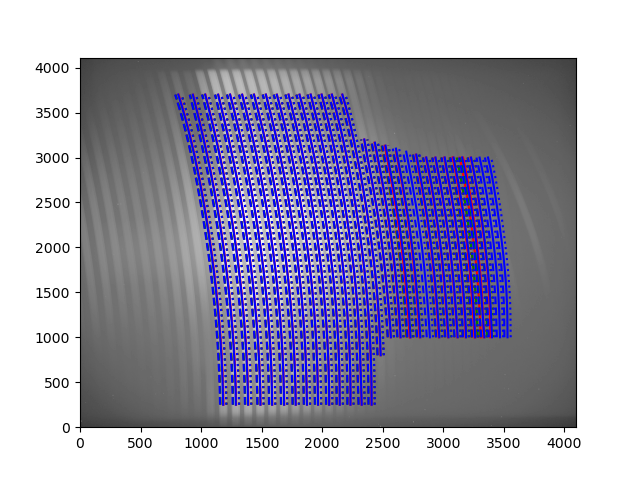

In [25]:
j = None

plt.figure()
plt.imshow(image_subtracted_bias, cmap='gray', norm="log", origin='lower', aspect='auto')
# plt.imshow(blured, cmap='gray', norm="log", origin='lower', aspect='auto')

if j is None:
    for trace_y, trace_x, lower_range, upper_range in new_traces:
        plt.plot(trace_x, trace_y, 'r')
        plt.plot(trace_x-lower_range, trace_y, 'r--')
        plt.plot(trace_x+upper_range, trace_y, 'r:')
        
        plt.plot(trace_x-25, trace_y, 'g--')
        plt.plot(trace_x+25, trace_y, 'g:')
    for trace_y, trace_x, lower_range, upper_range in traces:
        plt.plot(trace_x, trace_y, 'b')
        plt.plot(trace_x-lower_range, trace_y, 'b--')
        plt.plot(trace_x+upper_range, trace_y, 'b:')
elif j!=1:
    for trace_y, trace_x, lower_range, upper_range in zip(new_traces.y[-1*j:-1*j+1], new_traces.x[-1*j:-1*j+1], new_traces.summing_ranges_lower[-1*j:-1*j+1], new_traces.summing_ranges_upper[-1*j:-1*j+1]):
        plt.plot(trace_x, trace_y, 'r')
        plt.plot(trace_x-lower_range, trace_y, 'r--')
        plt.plot(trace_x+upper_range, trace_y, 'r:')
    for trace_y, trace_x, lower_range, upper_range in traces[-1*j:-1*j+1]:
        plt.plot(trace_x, trace_y, 'b')
        plt.plot(trace_x-lower_range, trace_y, 'b--')
        plt.plot(trace_x+upper_range, trace_y, 'b:')
else:
    for trace_y, trace_x, lower_range, upper_range in zip(new_traces.y[-1:], new_traces.x[-1:], new_traces.summing_ranges_lower[-1:], new_traces.summing_ranges_upper[-1:]):
        plt.plot(trace_x, trace_y, 'r')
        plt.plot(trace_x-lower_range, trace_y, 'r--')
        plt.plot(trace_x+upper_range, trace_y, 'r:')
    for trace_y, trace_x, lower_range, upper_range in traces[-1:]:
        plt.plot(trace_x, trace_y, 'b')
        plt.plot(trace_x-lower_range, trace_y, 'b--')
        plt.plot(trace_x+upper_range, trace_y, 'b:')

ylen, xlen = image_subtracted_bias.shape
# plt.xlim(0, xlen)
# plt.xlim(3420, 3530)
# plt.ylim(0, ylen)
# plt.ylim(2030, 2480)

plt.show()

In [ ]:
# order = 0

# plt.figure()
# plt.imshow(image_subtracted_bias, cmap='gray', norm="symlog", origin='lower', aspect='auto')

# plt.plot(new_traces.x[order], new_traces.y[order], 'r')
# plt.plot(new_traces.x[order]-new_traces.summing_ranges_lower[order], trace_y, 'r--')
# plt.plot(new_traces.x[order]+new_traces.summing_ranges_upper, new_traces.y[order], 'r:')

# ylen, xlen = image_subtracted_bias.shape
# plt.xlim(0, xlen)
# plt.ylim(0, ylen)

# plt.show()

In [54]:
plt.close('all')

In [46]:
len(new_traces)

40

In [ ]:
# new_traces.set_traces(new_traces.traces[0:-1])
# new_traces.set_summing_range(summing_ranges[0:-1])
# new_traces.wave_calib_slice = slice(None, -1)

In [ ]:
filename = f'veloce_{arm}_{amplifier_mode}amp_sim_calib_trace_{header["DATE-OBS"]}'
# filename = f'veloce_{arm}_{amplifier_mode}amp_no_sim_calib_trace'
# new_traces.save_traces(arm=arm, amplifier_mode=amplifier_mode, sim_calib=True, filename=filename, trace_dir=trace_path)

And now for the case with sim calib

In [ ]:
### science data with LC
# data_path = '/home/usqobserver2/VeloceData'
# run = 'CSV_Run'
# date = '230826'
# ccd = 'ccd_3'
det_num = ccd.split('_')[1]
filename = f'26aug{det_num}0148.fits'
# filename = f'04apr{det_num}0082.fits'
spectrum_filename =  os.path.join(input_dir, date, ccd, filename)

In [ ]:
### SimTh 
# data_path = '/home/usqobserver2/VeloceData'
# run = 'CSV_Run'
# date = '230826'
# ccd = 'ccd_2'
# filename = f'26aug20074.fits'
# spectrum_filename =  os.path.join(data_path, run, date, ccd, filename)

In [ ]:
with fits.open(spectrum_filename) as hdul:
    image_data = hdul[0].data
    header = hdul[0].header
image_subtracted_bias = veloce_reduction_tools.remove_overscan_bias(image_data, hdr=header, arm=arm, amplifier_mode=amplifier_mode, overscan_range=32)

Gain for half 1: 1.01
Gain for half 2: 0.97364


In [40]:
del image_data, header
gc.collect()

1748

In [41]:
%matplotlib inline

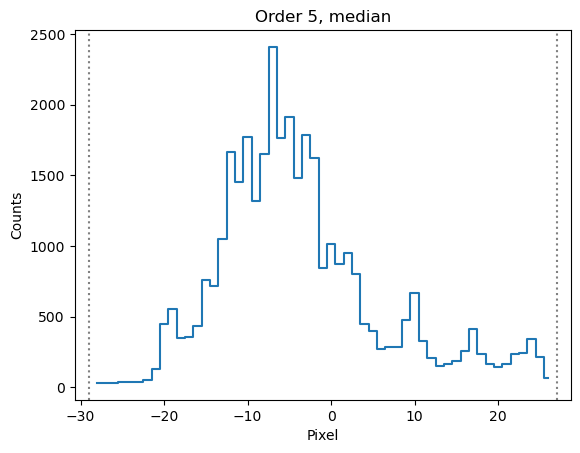

In [42]:
plt.figure()
order_img = veloce_reduction_tools.plot_order_cross_section(image_subtracted_bias, new_traces, 5, margin=[0,0])
plt.show()

In [121]:
plt.close()

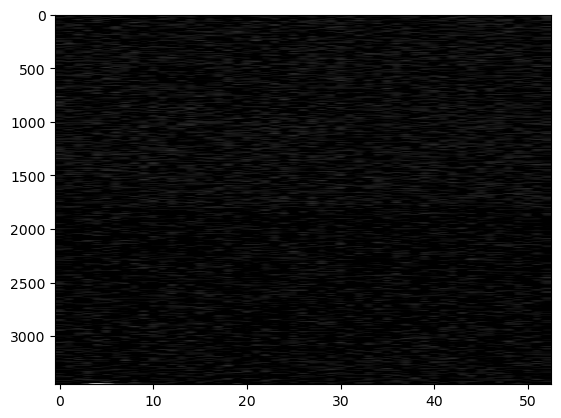

In [122]:
plt.figure()
plt.imshow(order_img, cmap='gray', norm='log', aspect='auto')
plt.show()

In [84]:
# plt.close()

In [112]:
del order_img
gc.collect()

3064

For red from CSV Run: (25,23) <br>
For green from CSV Run: (28,26) - sim calib, (36,36) - no calib <br>
For blue from CSV Run: () <br>

For green from Xmas run: () <br>
For red from Xmas Run: () <br>
For Blue from Xmas Run: () <br>

For green 2 amp mode: () <br>
For red 2 amp mode: () <br>
For blue 2 ampl mode: () <br>

In [26]:
%matplotlib widget

In [86]:
summing_ranges = [(26,26) for _ in range(len(new_traces.traces))]
new_traces.set_summing_range(summing_ranges)

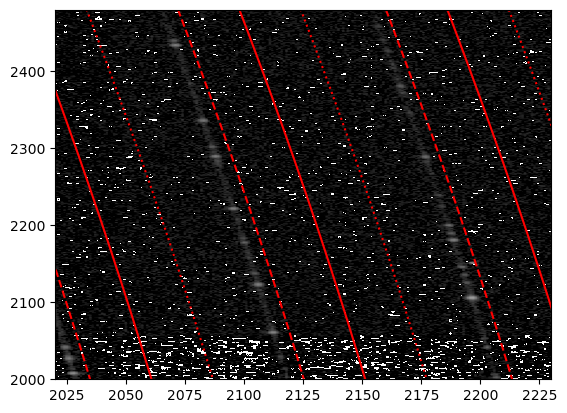

In [114]:
plt.figure()
plt.imshow(image_subtracted_bias, cmap='gray', norm="log", origin='lower', aspect='auto')

for trace_y, trace_x, lower_range, upper_range in new_traces:
    plt.plot(trace_x, trace_y, 'r')
    plt.plot(trace_x-lower_range, trace_y, 'r--')
    plt.plot(trace_x+upper_range, trace_y, 'r:')

ylen, xlen = image_subtracted_bias.shape
# plt.xlim(0, xlen)
plt.xlim(2020, 2230)
# plt.ylim(0, ylen)
plt.ylim(2000, 2480)

plt.show()

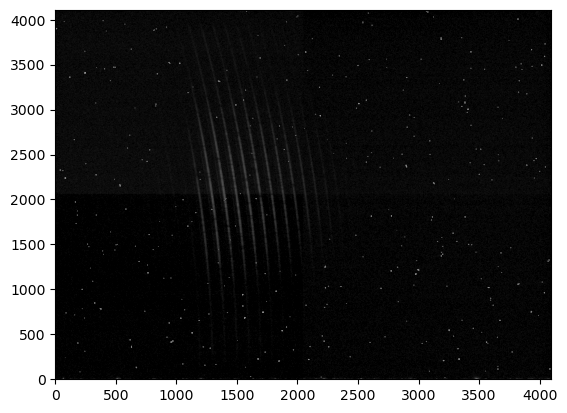

In [105]:
plt.figure()
plt.imshow(image_subtracted_bias, cmap='gray', norm="log", origin='lower', aspect='auto')
plt.show()

In [50]:
plt.close('all')

In [ ]:
# new_traces.save_traces(arm=arm, amplifier_mode=amplifier_mode, sim_calib=True)

### 5. Save traces

In [ ]:
### green from CSV Run - after inspection edge orders are incomplete and not usable
# traces=traces[1:-1]
# summing_ranges=summing_ranges[1:-1]

# np.savez('./Trace/veloce_green_4amp_trace', traces=traces, summing_ranges=summing_ranges)

In [ ]:
### red from CSV Run - after inspection first order (104) is incomplete and wasn't identified removing it from - loading data  
# traces=traces[1:-1]
# summing_ranges=summing_ranges[1:-1]

# np.savez('./Trace/veloce_green_4amp_no_sim_calib_trace', traces=traces, summing_ranges=summing_ranges)

In [ ]:
# save_traces(traces=adjusted_traces, summing_ranges=summing_ranges, wave_calib_slice=slice(None), filename='veloce_green_fromTh_4amp_no_sim_calib_trace')
# new_traces.save_traces(filename='veloce_green_4amp_no_sim_calib_trace')
# new_traces.save_traces(arm=arm, amplifier_mode=amplifier_mode, sim_calib=False)

### 6. Fit fibres composing pseudoslit

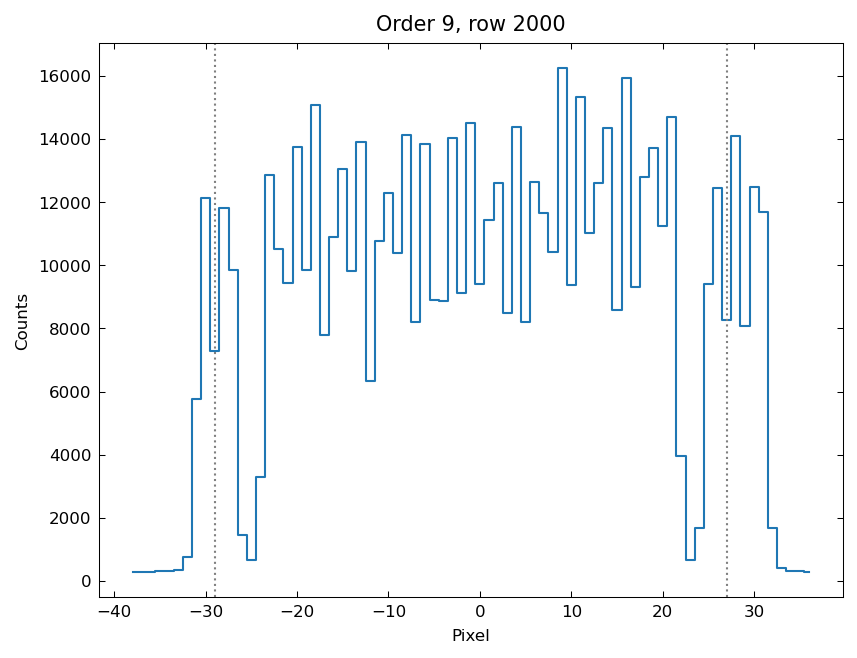

In [157]:
plt.close('all')
plt.figure()
extracted_order_image = veloce_reduction_tools.plot_order_cross_section(flat_subtracted_bias, traces, 9, plot_type=2000, margin=[10,10])    
plt.show()

In [158]:
lower, upper = traces.summing_ranges_lower[9], traces.summing_ranges_upper[9]

In [159]:
extracted_order_image

array([[10.74707826,  8.79306403,  6.8390498 , ..., 10.74707826,
        10.74707826, 18.56313518],
       [20.51714941,  3.90802846, 15.63211383, ..., 12.70109249,
         4.88503557,  9.77007115],
       [ 7.81605692, 10.74707826,  6.8390498 , ...,  8.79306403,
        20.51714941,  8.79306403],
       ...,
       [15.84158416, 22.77227723, 22.77227723, ..., 15.84158416,
        24.75247525, 14.85148515],
       [18.81188119, 24.75247525, 17.82178218, ...,  4.95049505,
        16.83168317, 18.81188119],
       [14.85148515, 21.78217822, 20.79207921, ..., 18.81188119,
        13.86138614, 10.89108911]], shape=(4111, 75))

Text(0, 0.5, 'Counts')

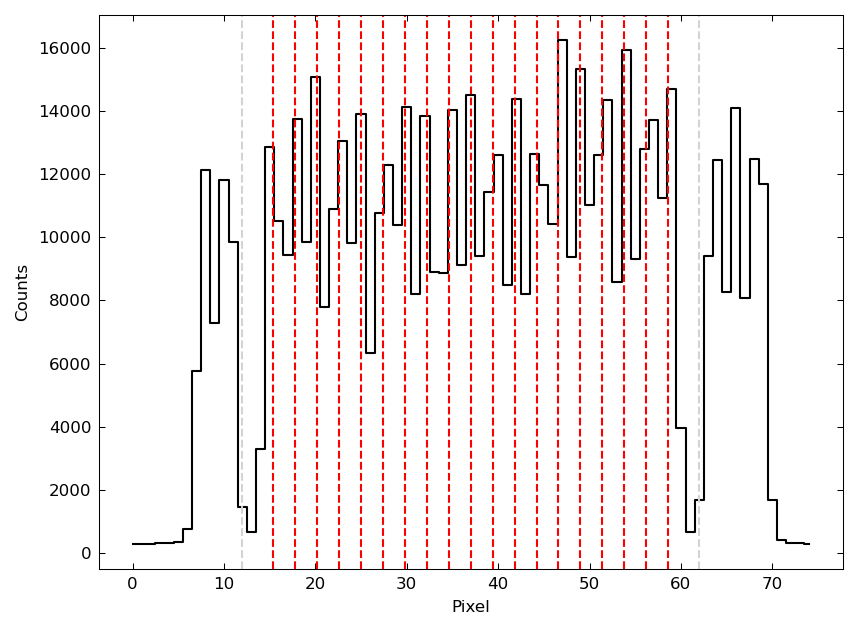

In [165]:
n_fibre = 9
fibre_spacing = 2.4
plt.step(extracted_order_image[2000], 'k-', where='mid')
x_pos = np.arange(extracted_order_image.shape[1])
x_mid = extracted_order_image.shape[1] // 2
mu_array = np.arange(x_mid-fibre_spacing*n_fibre, x_mid+fibre_spacing*(n_fibre+1), fibre_spacing)
for mu in mu_array:
    plt.axvline(mu, color='r', linestyle='--')
plt.axvline(12, color='lightgrey', linestyle='--')
plt.axvline(len(extracted_order_image[2000])-13, color='lightgrey', linestyle='--')
plt.xlabel('Pixel')
plt.ylabel('Counts')

In [183]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-np.abs(((x - mu)/(np.sqrt(2)*sigma)))**2)

def slit_params(x):
    n_fibre = 19
    x_mid = x[len(x)//2]
    fibre_spacing = 2.4
    sigma = 0.7
    # mu_array = np.arange(x_mid-fibre_spacing*n_fibre//2, x_mid+fibre_spacing*(n_fibre//2+1), fibre_spacing)
    # mu_array = np.array([13.30160124, 15.76222381, 18.04741708, 20.59243522, 22.8443981 ,
    #    25.53754426, 27.81605855, 30.24118369, 32.84204404, 35.14287515,
    #    37.56701876, 39.95260896, 42.41879959, 44.84669695, 47.24276235,
    #    49.60690297, 52.00784843, 54.46143611, 56.67070973])
    mu_array = np.array([15.35294256, 17.76338162, 19.99262427, 22.58330699, 24.84077377,
       27.54002691, 29.78649525, 32.20366219, 34.81494568, 37.14599315,
       39.56663317, 41.98547757, 44.43774537, 46.84278222, 49.23755342,
       51.59969121, 54.07079069, 56.51419267, 58.73416212])
    
    return n_fibre, x_mid, fibre_spacing, mu_array, sigma

def multi_gaussian(x, *params):
    n_fibre, x_mid, fibre_spacing, mu_array, sigma = slit_params(x)
    
    if len(params) != n_fibre * 2:
        raise ValueError(f'Expected {n_fibre * 2} parameters, but got {len(params)}')
    
    result = np.zeros_like(x, dtype=float)
    for i in range(n_fibre):
        A = params[2*i]
        mu = mu_array[i]
        # mu = params[2*i+1]
        sigma = params[2*i+1]
        result += gaussian(x, A, mu, sigma)
    return result



In [184]:
# fit multi-gaussian to the extracted order profile
from scipy.optimize import curve_fit
x = np.arange(extracted_order_image.shape[1])

flux_fit = extracted_order_image[2000].copy()
flux_fit -= np.min(flux_fit)
flux_fit[:12] = 0
flux_fit[-13:] = 0
n_fibre, x_mid, fibre_spacing, mu_array, sigma = slit_params(x)
initial_guess = []
for a, _mu in zip([np.max(extracted_order_image[2000])]*n_fibre, mu_array):
    initial_guess.append(a)
    # initial_guess.append(_mu)
    initial_guess.append(sigma)
popt, pcov = curve_fit(multi_gaussian, x, flux_fit, p0=initial_guess)



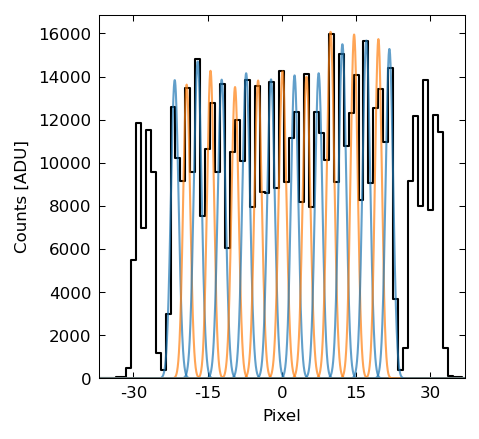

In [194]:
color_list = ["C0", "C1"]
plt.figure(figsize=(3.15, 3.15))
# plt.figure(figsize=(7.5, 3.15))
plt.step(extracted_order_image[2000]-np.min(extracted_order_image[2000]), 'k-', where='mid', label='Data')
# plt.step(flux_fit, 'b-', where='mid', label='Data')
fine_x = np.linspace(x[0], x[-1], 5000)
combined_fit = np.zeros_like(fine_x)
sigma = 0.7
for i in range(len(popt)//2):
    a = popt[2*i]
    # mu = popt[2*i+1]
    mu = mu_array[i]
    sigma = popt[2*i+1]
    combined_fit += gaussian(fine_x, a, mu, sigma)
    plt.plot(fine_x, gaussian(fine_x, a, mu, sigma), c = color_list[i%2], linestyle='-', alpha=0.7, label='Individual Gaussians' if mu == popt[1] else None)
# plt.plot(fine_x, combined_fit, c='C3', label='Fit')
# x_ref = np.arange(-lower-10,upper+10+1)
xlen = len(extracted_order_image[2000])
xticks = [7, (6+xlen//2)//2+1,  xlen//2, xlen//2+15, xlen-8]
xlabels = [str(int(tick)) for tick in xticks]
for i, tick in enumerate(xticks):
    xlabels[i] = f'{tick-x_mid}'
plt.xticks(xticks, xlabels)
# plt.xticks(xticks)
plt.xlabel('Pixel')
plt.ylabel('Counts [ADU]')
# plt.legend()
plt.xlim(x[0], x[-1])
plt.ylim(0,)
plt.savefig(f'cross-section_with_multi_gaussian_fit_{arm}_order_{ORDER[9]}.pdf', dpi=600, bbox_inches='tight')
# plt.savefig(f'cross-section_with_multi_gaussian_fit_{arm}_order_{ORDER[9]}_2col.pdf', dpi=600, bbox_inches='tight')
plt.show()

In [179]:
fixed_mu_array = popt[1::2]
for i in range(len(fixed_mu_array)):
    print(f'Fibre {i+1}: mu = {fixed_mu_array[i]}, deviation from expected position = {fixed_mu_array[i]-mu_array[i]}')

Fibre 1: mu = 15.35294255790274, deviation from expected position = 0.35294255790273965
Fibre 2: mu = 17.763381624294524, deviation from expected position = 0.3633816242945258
Fibre 3: mu = 19.99262426998033, deviation from expected position = 0.19262426998033177
Fibre 4: mu = 22.583306990804545, deviation from expected position = 0.3833069908045488
Fibre 5: mu = 24.84077377017254, deviation from expected position = 0.2407737701725452
Fibre 6: mu = 27.540026909008017, deviation from expected position = 0.5400269090080236
Fibre 7: mu = 29.786495250218643, deviation from expected position = 0.38649525021865117
Fibre 8: mu = 32.2036621893598, deviation from expected position = 0.4036621893598067
Fibre 9: mu = 34.81494567868601, deviation from expected position = 0.6149456786860199
Fibre 10: mu = 37.14599315212664, deviation from expected position = 0.5459931521266554
Fibre 11: mu = 39.56663317174418, deviation from expected position = 0.5666331717441935
Fibre 12: mu = 41.98547757264782, d

In [180]:
fixed_mu_array = np.array(fixed_mu_array)
np.diff(fixed_mu_array)

array([2.41043907, 2.22924265, 2.59068272, 2.25746678, 2.69925314,
       2.24646834, 2.41716694, 2.61128349, 2.33104747, 2.42064002,
       2.4188444 , 2.4522678 , 2.40503685, 2.3947712 , 2.36213778,
       2.47109949, 2.44340197, 2.21996946])

In [181]:
fixed_mu_array

array([15.35294256, 17.76338162, 19.99262427, 22.58330699, 24.84077377,
       27.54002691, 29.78649525, 32.20366219, 34.81494568, 37.14599315,
       39.56663317, 41.98547757, 44.43774537, 46.84278222, 49.23755342,
       51.59969121, 54.07079069, 56.51419267, 58.73416212])

In [189]:
fixed_sigma_array = popt[1::2]
for i in range(len(fixed_sigma_array)):
    print(f'Fibre {i+1}: sigma = {fixed_sigma_array[i]}, deviation from expected position = {fixed_sigma_array[i]-sigma}')

Fibre 1: sigma = 0.7753384511676213, deviation from expected position = 0.022971034259832157
Fibre 2: sigma = 0.7086249431067659, deviation from expected position = -0.04374247380102325
Fibre 3: sigma = 0.7849501393652725, deviation from expected position = 0.03258272245748328
Fibre 4: sigma = 0.6937753795443656, deviation from expected position = -0.058592037363423555
Fibre 5: sigma = 0.7850939619402405, deviation from expected position = 0.032726545032451315
Fibre 6: sigma = 0.7174929016030277, deviation from expected position = -0.03487451530476149
Fibre 7: sigma = 0.7724585954449976, deviation from expected position = 0.02009117853720843
Fibre 8: sigma = 0.7487318531366715, deviation from expected position = -0.0036355637711177335
Fibre 9: sigma = 0.7604511898895177, deviation from expected position = 0.008083772981728465
Fibre 10: sigma = 0.7694629397872568, deviation from expected position = 0.017095522879467584
Fibre 11: sigma = 0.7314361010601315, deviation from expected positi

In [190]:
fixed_sigma_array = np.array(fixed_sigma_array)
np.diff(fixed_sigma_array)

array([-0.06671351,  0.0763252 , -0.09117476,  0.09131858, -0.06760106,
        0.05496569, -0.02372674,  0.01171934,  0.00901175, -0.03802684,
        0.03603913, -0.02954412,  0.01571544,  0.01084826, -0.05006402,
        0.05721695, -0.08362324,  0.06434291])